<a href="https://colab.research.google.com/github/debashisdotchatterjee/Bayesian-Dynamic-Game-1/blob/main/Bayesian_Dynamic_Game_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Output directory: /content/bayesian_game_simulation_outputs

Running policy: Proposed_Bayesian_CredibleRisk
Completed policy: Proposed_Bayesian_CredibleRisk

Running policy: Bayesian_RiskNeutral
Completed policy: Bayesian_RiskNeutral

Running policy: Classical_StaticPrior
Completed policy: Classical_StaticPrior

Simulation finished in 874.96 seconds

Head of panel data:


,replication,policy,t,cost1,cost2,type1,type2,price1,qty1,price2,...,post_b0_1,post_b1_1,post_b2_1,post_b3_1,post_b0_2,post_b1_2,post_b2_2,post_b3_2,mse_beta_firm1,mse_beta_firm2
0,1,Proposed_Bayesian_CredibleRisk,1,6.0,10.0,low,high,8,20,8,...,37.150914,-1.311707,1.188293,3.344146,35.848050,-1.728624,0.771376,3.135688,21.028921,26.622792
1,1,Proposed_Bayesian_CredibleRisk,2,6.0,10.0,low,high,16,35,13,...,46.038764,-3.322620,0.998014,7.193714,39.339651,-1.803375,-0.018613,4.647995,0.322645,11.221591
2,1,Proposed_Bayesian_CredibleRisk,3,6.0,10.0,low,high,12,20,12,...,46.033169,-3.313120,0.983655,7.213341,39.117035,-2.374759,0.359417,5.428995,0.319679,10.276535
3,1,Proposed_Bayesian_CredibleRisk,4,6.0,10.0,low,high,12,20,11,...,47.249654,-3.425942,0.888397,4.952668,40.186884,-2.316276,0.334317,4.838909,2.919310,8.161211
4,1,Proposed_Bayesian_CredibleRisk,5,6.0,10.0,low,high,11,20,11,...,46.352622,-3.234488,0.677627,5.555805,40.214144,-2.307374,0.326492,4.823071,1.503989,8.126065


Saved table: period_summary.csv
Saved table: replication_summary.csv
Saved table: overall_summary.csv
Saved table: proposed_vs_baselines.csv

Overall summary:


,policy,mean_total_profit_market,sd_total_profit_market,median_total_profit_market,mean_final_mse,sd_final_mse,mean_profit1,mean_profit2
0,Bayesian_RiskNeutral,1593.286067,1211.319621,1608.329060,17.328267,14.268422,929.461812,663.824254
1,Classical_StaticPrior,67.010297,1347.330737,0.000000,30.825000,0.000000,141.905193,-74.894896
2,Proposed_Bayesian_CredibleRisk,1597.295828,1351.406749,1678.978909,17.657276,14.418801,933.787278,663.508550



Improvement table:


,comparison_against,profit_gain_pct_of_proposed_vs_baseline,mse_reduction_pct_of_proposed_vs_baseline
0,Bayesian_RiskNeutral,0.251666,-1.898683
1,Classical_StaticPrior,2283.657294,42.717676


Saved table: bootstrap_comparisons.csv

Bootstrap comparison table:


,comparison,boot_mean_diff_profit,profit_95CI_low,profit_95CI_high,boot_mean_diff_mse,mse_95CI_low,mse_95CI_high
0,Proposed_Bayesian_CredibleRisk - Bayesian_Risk...,2.437007,-280.454851,295.430180,0.438492,-2.895554,3.575155
1,Proposed_Bayesian_CredibleRisk - Classical_Sta...,1533.021055,1228.650336,1839.138063,-13.116479,-15.371465,-10.644336


Saved figure: cum_discounted_market_profit.png


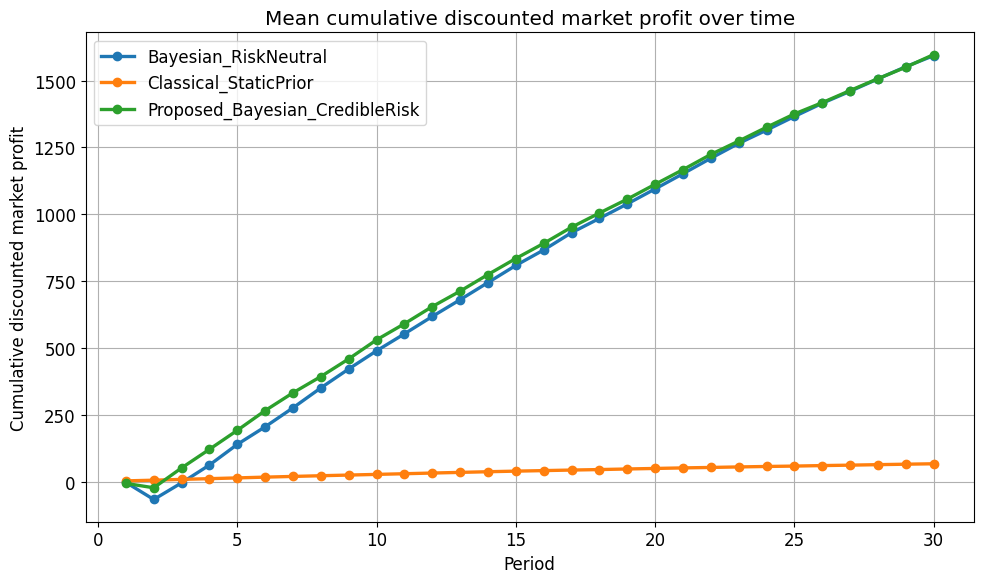

Saved figure: boxplot_final_market_profit.png


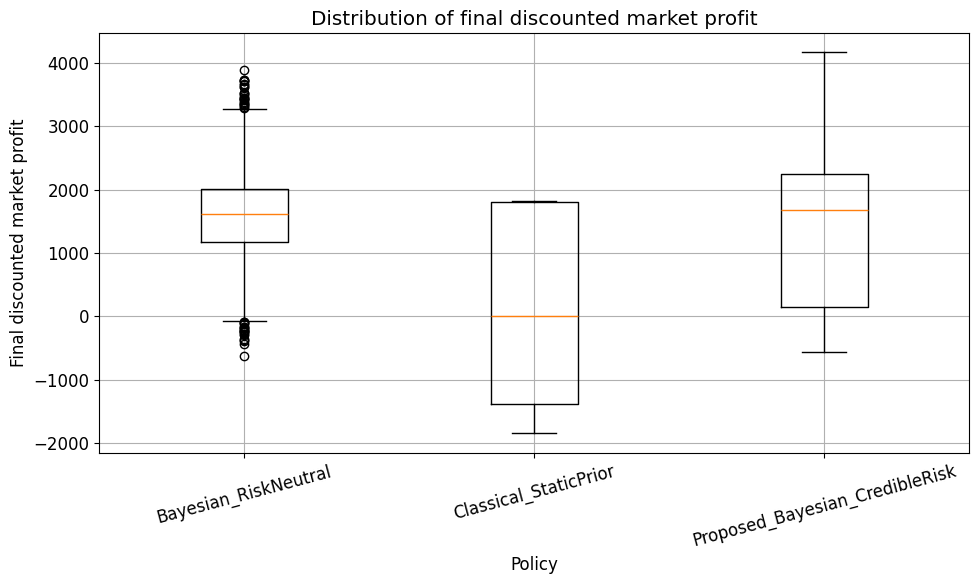

Saved figure: hist_final_mse.png


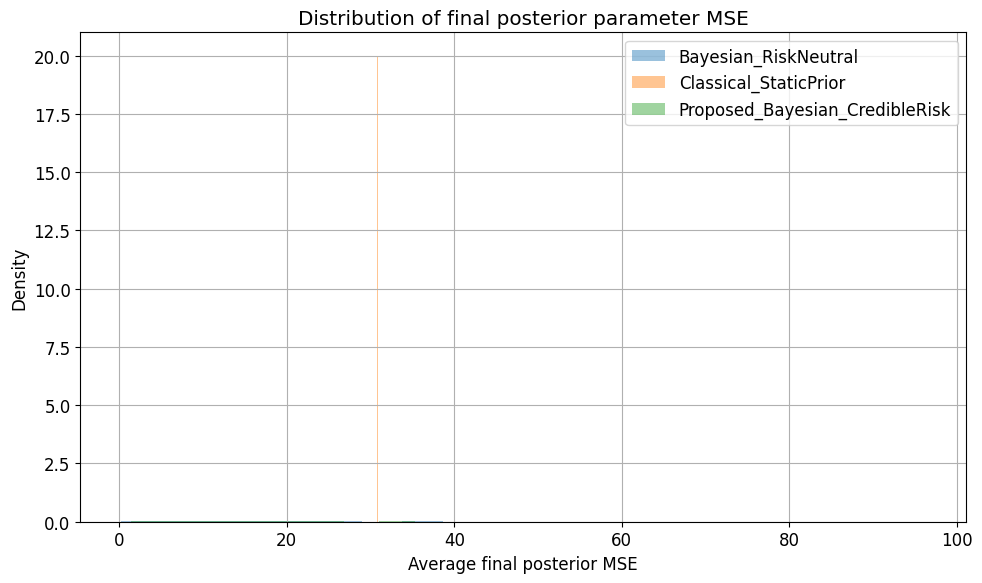

Saved figure: stockout_rate_over_time.png


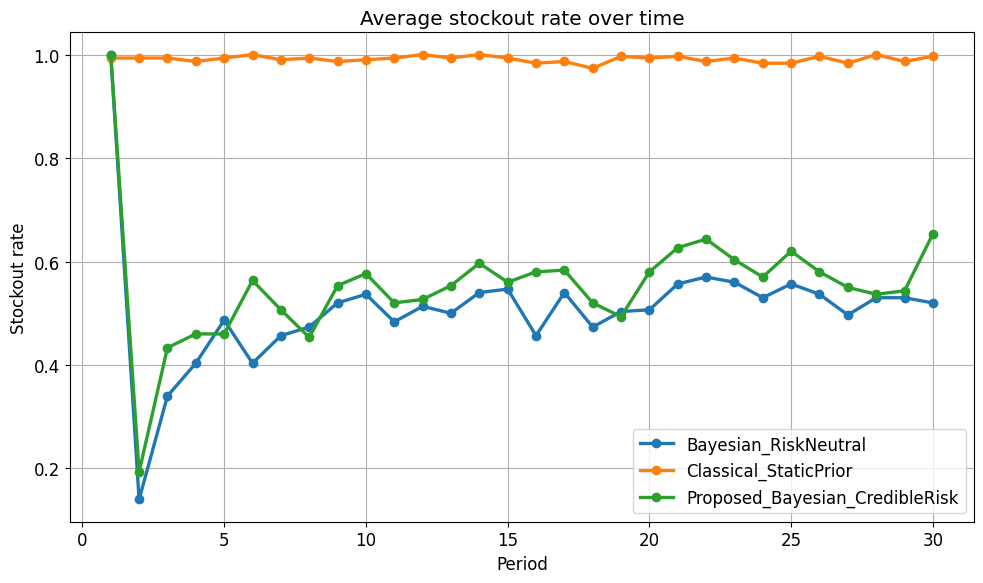

Saved figure: average_price_over_time.png


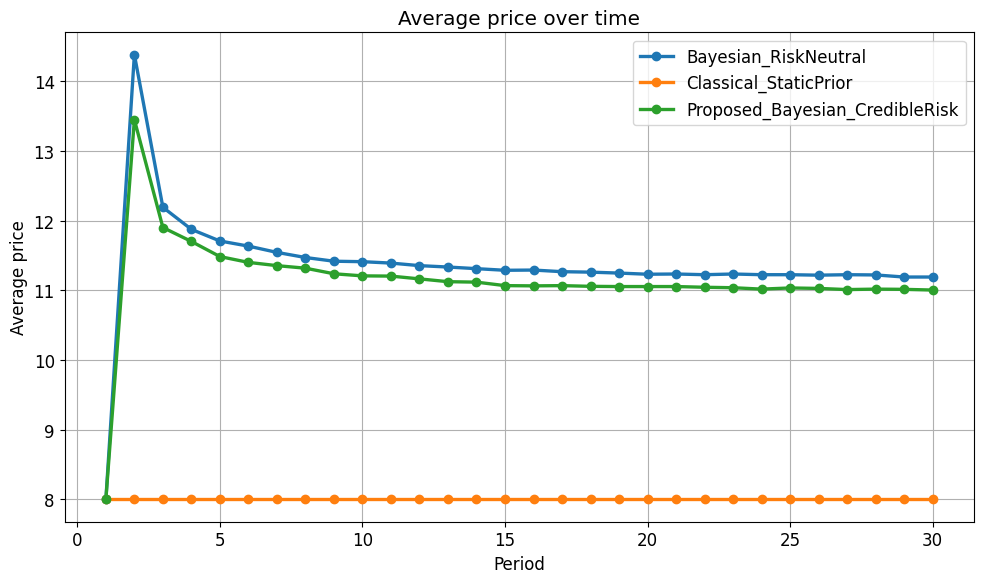

Saved figure: average_quantity_over_time.png


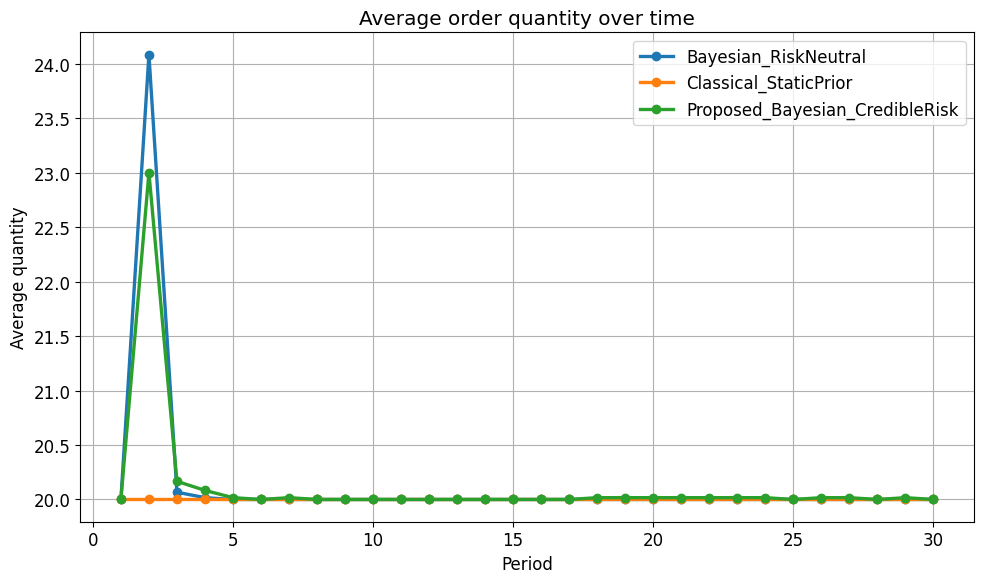

Saved figure: parameter_mse_over_time.png


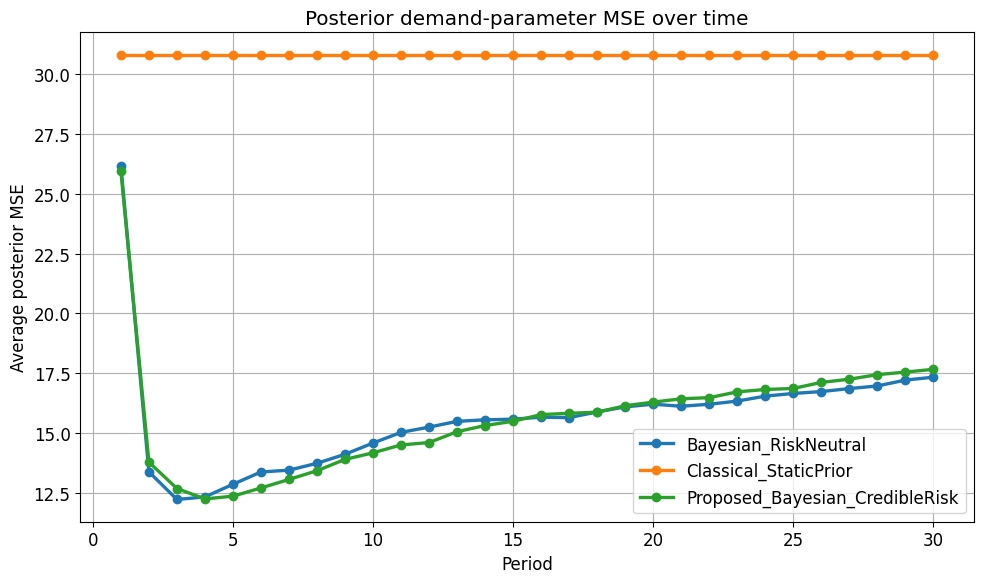

Saved figure: belief_learning_curve.png


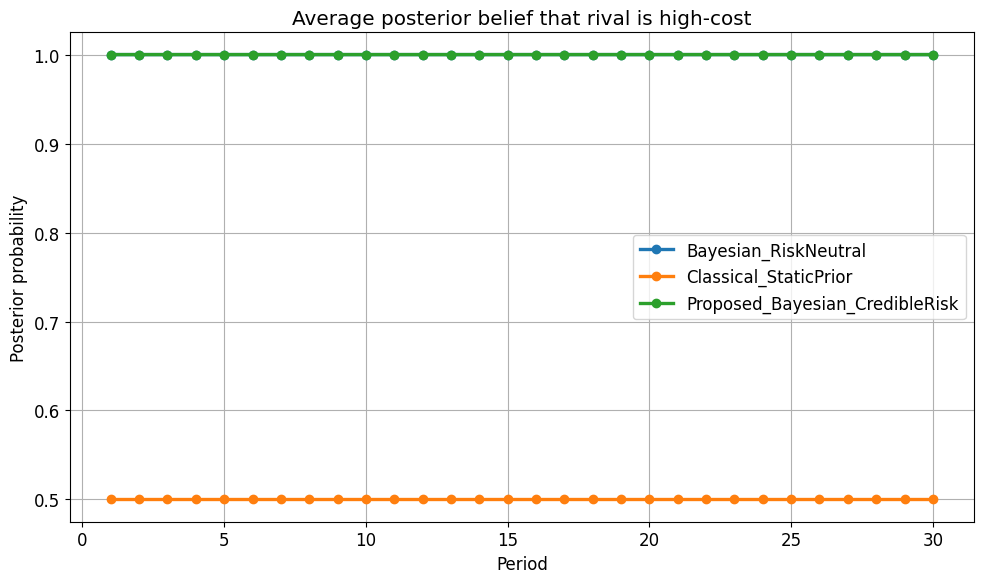

Saved figure: objective_surface_heatmap.png


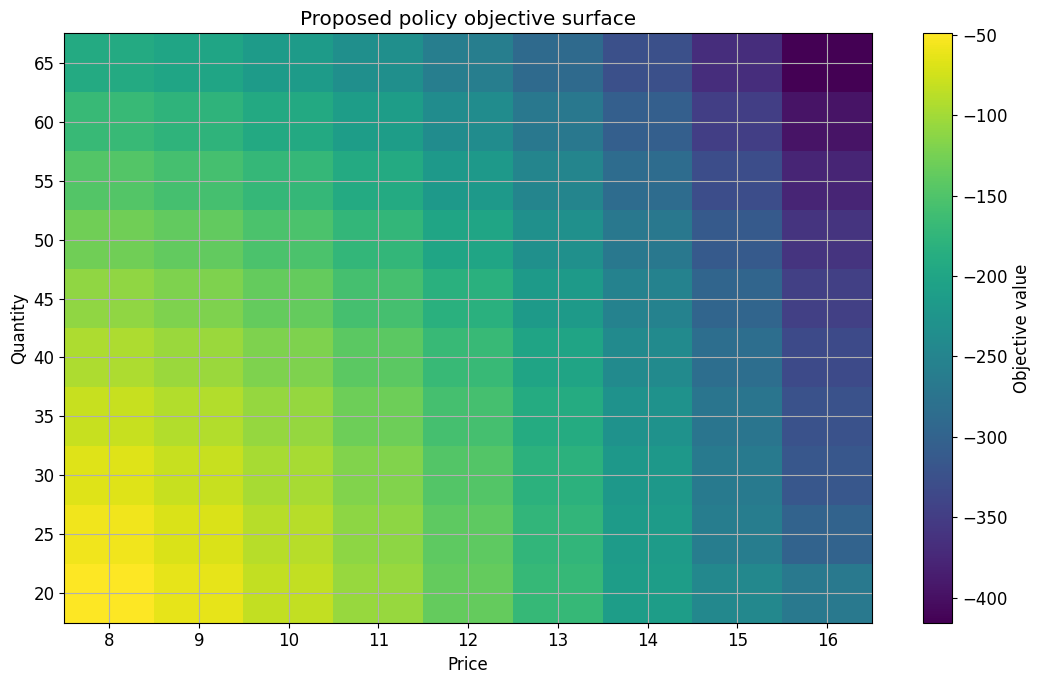

Saved figure: scatter_profit_vs_mse.png


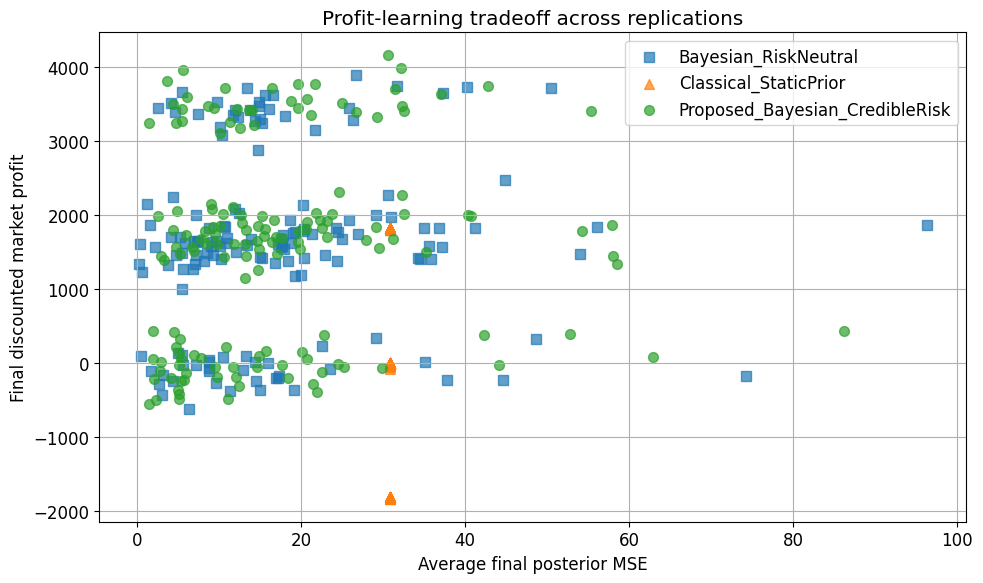

Saved figure: density_final_market_profit.png


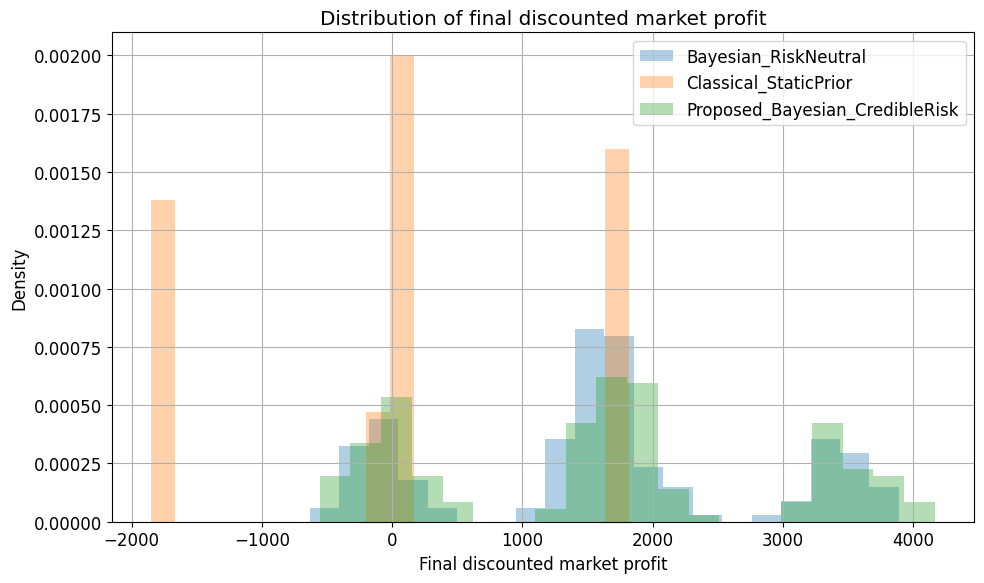

Saved figure: dominance_probability_over_time.png


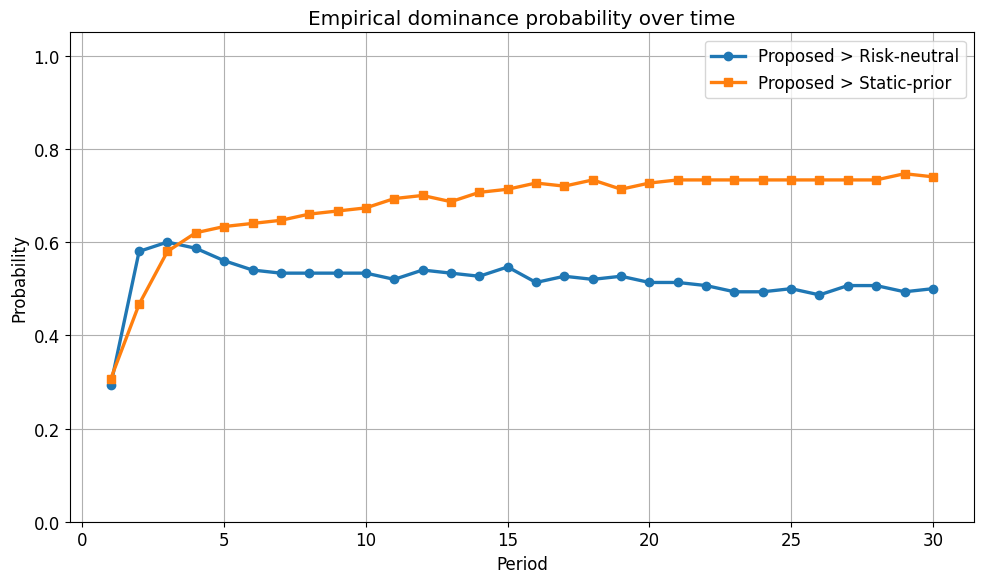

Saved table: publication_style_main_results.csv

Publication-style main results:


,policy,mean_total_profit_market,sd_total_profit_market,median_total_profit_market,mean_final_mse,sd_final_mse,mean_profit1,mean_profit2
0,Bayesian_RiskNeutral,1593.29,1211.32,1608.33,17.3283,14.2684,929.46,663.82
1,Classical_StaticPrior,67.01,1347.33,0.00,30.8250,0.0000,141.91,-74.89
2,Proposed_Bayesian_CredibleRisk,1597.30,1351.41,1678.98,17.6573,14.4188,933.79,663.51



ZIP file created: /content/bayesian_game_simulation_outputs.zip

If you want, uncomment the next line to download automatically:
files.download('bayesian_game_simulation_outputs.zip')

Done.


In [1]:
# ============================================================
#  PYTHON SCRIPT
# Bayesian Game-Theoretic Simulation Study
# ============================================================

# ------------------------------------------------------------
# 0. Imports
# ------------------------------------------------------------
import os
import json
import math
import time
import zipfile
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from IPython.display import display

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. Global setup
# ------------------------------------------------------------
GLOBAL_SEED = 20260306
np.random.seed(GLOBAL_SEED)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12

BASE_DIR = Path.cwd() / "bayesian_game_simulation_outputs"
FIG_DIR = BASE_DIR / "figures"
TAB_DIR = BASE_DIR / "tables"
RAW_DIR = BASE_DIR / "raw_data"

for d in [BASE_DIR, FIG_DIR, TAB_DIR, RAW_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Output directory:", BASE_DIR.resolve())

# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------
def clamp(x, lo, hi):
    return max(lo, min(hi, float(x)))

def ensure_nonnegative(x):
    return max(0.0, float(x))

def save_table(df, name):
    csv_path = TAB_DIR / f"{name}.csv"
    xlsx_path = TAB_DIR / f"{name}.xlsx"
    df.to_csv(csv_path, index=False)
    try:
        df.to_excel(xlsx_path, index=False)
    except Exception as e:
        print(f"Excel export skipped for {name}: {e}")
    print(f"Saved table: {csv_path.name}")

def savefig(name):
    png_path = FIG_DIR / f"{name}.png"
    pdf_path = FIG_DIR / f"{name}.pdf"
    plt.tight_layout()
    plt.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.savefig(pdf_path, dpi=200, bbox_inches="tight")
    print(f"Saved figure: {png_path.name}")

def one_step_profit(sales, q, unit_cost, price, holding_cost, salvage_value):
    leftover = max(q - sales, 0.0)
    return price * sales - unit_cost * q - holding_cost * leftover + salvage_value * leftover

def normal_posterior_update(m, S, sigma2, x, y):
    """
    Bayesian linear regression update:
    Prior: beta ~ N(m, S)
    Likelihood: y | beta ~ N(x'beta, sigma2)
    """
    x = np.asarray(x).reshape(-1, 1)
    m = np.asarray(m).reshape(-1, 1)
    Sx = S @ x
    denom = float(sigma2 + (x.T @ Sx)[0, 0])
    K = Sx / denom
    resid = float(y - (x.T @ m)[0, 0])
    m_new = m + K * resid
    S_new = S - K @ x.T @ S
    return m_new.ravel(), S_new

def predictive_mean_var(m, S, sigma2, x):
    x = np.asarray(x).reshape(-1, 1)
    m = np.asarray(m).reshape(-1, 1)
    mu = float((x.T @ m)[0, 0])
    var = float(sigma2 + (x.T @ S @ x)[0, 0])
    return mu, max(var, 1e-8)

def bootstrap_diff_mean(x, y, B=2000, seed=1234):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    diffs = np.zeros(B)
    for b in range(B):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        diffs[b] = xb.mean() - yb.mean()
    mean_diff = diffs.mean()
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    return mean_diff, lo, hi

# ------------------------------------------------------------
# 3. Configuration
# ------------------------------------------------------------
@dataclass
class Config:
    horizon: int = 30
    n_replications: int = 150
    discount: float = 0.98

    # True demand model:
    # D_i = beta0 + beta1*p_i + beta2*p_j + beta3*stockout_j + eps
    beta0_true: float = 45.0
    beta1_true: float = -3.6
    beta2_true: float = 1.2
    beta3_true: float = 7.5
    sigma_true: float = 4.5

    # Private costs
    cost_low: float = 6.0
    cost_high: float = 10.0
    prob_high_cost_firm1: float = 0.45
    prob_high_cost_firm2: float = 0.55

    # Inventory economics
    holding_cost: float = 0.8
    salvage_value: float = 1.5

    # Strategy grids
    price_grid: tuple = (8, 9, 10, 11, 12, 13, 14, 15, 16)
    qty_grid: tuple = (20, 25, 30, 35, 40, 45, 50, 55, 60, 65)

    # Bayesian prior for demand coefficients [beta0, beta1, beta2, beta3]
    prior_mean: tuple = (35.0, -2.0, 0.5, 3.0)
    prior_sd: tuple = (10.0, 2.0, 2.0, 4.0)

    # Proposed credible-risk parameter
    kappa_proposed: float = 0.60
    kappa_risk_neutral: float = 0.0

    # Prior beliefs on rival high-cost type
    prior_high_cost_belief_firm1_about_2: float = 0.50
    prior_high_cost_belief_firm2_about_1: float = 0.50

    # Type-signal noise
    signaling_noise_sd: float = 4.0

cfg = Config()

# ------------------------------------------------------------
# 4. Market primitives
# ------------------------------------------------------------
def draw_cost(prob_high, cfg, rng):
    is_high = rng.random() < prob_high
    return (cfg.cost_high if is_high else cfg.cost_low), ("high" if is_high else "low")

def type_signal_mean(cost_type, cfg):
    # Low-cost firms act more aggressively on average
    return 26.0 if cost_type == "low" else 12.0

def aggressiveness_signal(price, qty):
    # More aggressive = higher quantity, lower price
    return qty - 2.2 * price

def update_high_cost_probability(prior_high_prob, observed_signal, cfg):
    mu_low = type_signal_mean("low", cfg)
    mu_high = type_signal_mean("high", cfg)
    sd = cfg.signaling_noise_sd

    like_high = norm.pdf(observed_signal, loc=mu_high, scale=sd)
    like_low = norm.pdf(observed_signal, loc=mu_low, scale=sd)

    numer = prior_high_prob * like_high
    denom = numer + (1 - prior_high_prob) * like_low

    if denom <= 1e-12:
        return prior_high_prob
    return numer / denom

def true_demand(p_i, p_j, stockout_j, cfg, rng):
    mu = cfg.beta0_true + cfg.beta1_true * p_i + cfg.beta2_true * p_j + cfg.beta3_true * float(stockout_j)
    d = mu + rng.normal(0, cfg.sigma_true)
    return max(0.0, d)

# ------------------------------------------------------------
# 5. Policy evaluation
# ------------------------------------------------------------
def evaluate_action(q_i, p_i, p_j, m_i, S_i, sigma2, opponent_high_cost_prob, own_unit_cost, cfg, kappa=0.0):
    """
    One-step approximate Bayesian objective:
      posterior mean profit - kappa * posterior sd(profit)
    """

    # Rival quantity proxy based on belief about rival type
    qj_low = 52.0
    qj_high = 40.0
    expected_qj = (1 - opponent_high_cost_prob) * qj_low + opponent_high_cost_prob * qj_high

    # Rival stockout probability proxy
    rival_demand_mean = cfg.beta0_true + cfg.beta1_true * p_j + cfg.beta2_true * p_i
    rival_stockout_prob = 1 - norm.cdf((expected_qj - rival_demand_mean) / cfg.sigma_true)
    rival_stockout_prob = clamp(rival_stockout_prob, 0.0, 1.0)

    x = np.array([1.0, p_i, p_j, rival_stockout_prob], dtype=float)
    mu_d, var_d = predictive_mean_var(m_i, S_i, sigma2, x)
    sd_d = math.sqrt(var_d)

    # E[min(D, q)] for normal approximation
    z = (q_i - mu_d) / sd_d
    Phi = norm.cdf(z)
    phi = norm.pdf(z)
    expected_sales = mu_d * Phi - sd_d * phi + q_i * (1 - Phi)
    expected_sales = clamp(expected_sales, 0.0, q_i)

    # Approximate sales variance
    censor_weight = Phi * (1 - 0.35 * Phi)
    var_sales = max(0.10, var_d * censor_weight)
    sd_sales = math.sqrt(var_sales)

    profit_mean = one_step_profit(
        sales=expected_sales,
        q=q_i,
        unit_cost=own_unit_cost,
        price=p_i,
        holding_cost=cfg.holding_cost,
        salvage_value=cfg.salvage_value
    )

    unit_margin = max(0.0, p_i - own_unit_cost + cfg.holding_cost - cfg.salvage_value)
    profit_sd = unit_margin * sd_sales

    objective = profit_mean - kappa * profit_sd

    return {
        "objective": objective,
        "profit_mean": profit_mean,
        "profit_sd": profit_sd,
        "expected_sales": expected_sales,
        "mu_d": mu_d,
        "sd_d": sd_d,
        "rival_stockout_prob": rival_stockout_prob
    }

def choose_action_bayesian(m_i, S_i, sigma2, opponent_high_cost_prob, own_unit_cost, cfg, kappa):
    best = None
    candidate_pj = 12.0 if opponent_high_cost_prob < 0.5 else 13.0

    for p_i in cfg.price_grid:
        for q_i in cfg.qty_grid:
            out = evaluate_action(
                q_i=q_i,
                p_i=p_i,
                p_j=candidate_pj,
                m_i=m_i,
                S_i=S_i,
                sigma2=sigma2,
                opponent_high_cost_prob=opponent_high_cost_prob,
                own_unit_cost=own_unit_cost,
                cfg=cfg,
                kappa=kappa
            )
            item = {"price": p_i, "qty": q_i, **out}
            if (best is None) or (item["objective"] > best["objective"]):
                best = item
    return best

def choose_action_static_prior(own_unit_cost, cfg):
    m0 = np.array(cfg.prior_mean, dtype=float)
    S0 = np.diag(np.array(cfg.prior_sd, dtype=float) ** 2)
    return choose_action_bayesian(
        m_i=m0,
        S_i=S0,
        sigma2=cfg.sigma_true ** 2,
        opponent_high_cost_prob=0.5,
        own_unit_cost=own_unit_cost,
        cfg=cfg,
        kappa=0.0
    )

# ------------------------------------------------------------
# 6. One replication
# ------------------------------------------------------------
def run_replication(policy_name, replication_id, cfg, seed):
    rng = np.random.default_rng(seed)

    # Draw private costs
    c1, t1 = draw_cost(cfg.prob_high_cost_firm1, cfg, rng)
    c2, t2 = draw_cost(cfg.prob_high_cost_firm2, cfg, rng)

    # Prior for demand coefficients
    m1 = np.array(cfg.prior_mean, dtype=float)
    m2 = np.array(cfg.prior_mean, dtype=float)
    S1 = np.diag(np.array(cfg.prior_sd, dtype=float) ** 2)
    S2 = np.diag(np.array(cfg.prior_sd, dtype=float) ** 2)
    sigma2 = cfg.sigma_true ** 2

    # Beliefs on rival type
    highprob_1about2 = cfg.prior_high_cost_belief_firm1_about_2
    highprob_2about1 = cfg.prior_high_cost_belief_firm2_about_1

    rows = []
    cum_profit1 = 0.0
    cum_profit2 = 0.0

    for t in range(1, cfg.horizon + 1):
        # Choose actions
        if policy_name == "Proposed_Bayesian_CredibleRisk":
            a1 = choose_action_bayesian(m1, S1, sigma2, highprob_1about2, c1, cfg, cfg.kappa_proposed)
            a2 = choose_action_bayesian(m2, S2, sigma2, highprob_2about1, c2, cfg, cfg.kappa_proposed)

        elif policy_name == "Bayesian_RiskNeutral":
            a1 = choose_action_bayesian(m1, S1, sigma2, highprob_1about2, c1, cfg, cfg.kappa_risk_neutral)
            a2 = choose_action_bayesian(m2, S2, sigma2, highprob_2about1, c2, cfg, cfg.kappa_risk_neutral)

        elif policy_name == "Classical_StaticPrior":
            a1 = choose_action_static_prior(c1, cfg)
            a2 = choose_action_static_prior(c2, cfg)

        else:
            raise ValueError("Unknown policy name")

        # First-stage demand without realized substitution
        D1_base = true_demand(a1["price"], a2["price"], 0, cfg, rng)
        D2_base = true_demand(a2["price"], a1["price"], 0, cfg, rng)

        stockout1_base = float(D1_base > a1["qty"])
        stockout2_base = float(D2_base > a2["qty"])

        # One substitution correction
        D1 = max(0.0, D1_base + cfg.beta3_true * stockout2_base)
        D2 = max(0.0, D2_base + cfg.beta3_true * stockout1_base)

        sales1 = min(a1["qty"], D1)
        sales2 = min(a2["qty"], D2)

        stockout1 = float(D1 > a1["qty"])
        stockout2 = float(D2 > a2["qty"])

        leftover1 = max(a1["qty"] - sales1, 0.0)
        leftover2 = max(a2["qty"] - sales2, 0.0)

        profit1 = one_step_profit(sales1, a1["qty"], c1, a1["price"], cfg.holding_cost, cfg.salvage_value)
        profit2 = one_step_profit(sales2, a2["qty"], c2, a2["price"], cfg.holding_cost, cfg.salvage_value)

        cum_profit1 += (cfg.discount ** (t - 1)) * profit1
        cum_profit2 += (cfg.discount ** (t - 1)) * profit2

        # Bayesian updating only for learning-based policies
        x1 = np.array([1.0, a1["price"], a2["price"], stockout2], dtype=float)
        x2 = np.array([1.0, a2["price"], a1["price"], stockout1], dtype=float)

        if policy_name in ["Proposed_Bayesian_CredibleRisk", "Bayesian_RiskNeutral"]:
            # In the simulation we update using realized latent demand
            m1, S1 = normal_posterior_update(m1, S1, sigma2, x1, D1)
            m2, S2 = normal_posterior_update(m2, S2, sigma2, x2, D2)

            sig2 = aggressiveness_signal(a2["price"], a2["qty"])
            sig1 = aggressiveness_signal(a1["price"], a1["qty"])

            highprob_1about2 = update_high_cost_probability(highprob_1about2, sig2, cfg)
            highprob_2about1 = update_high_cost_probability(highprob_2about1, sig1, cfg)

        true_beta = np.array([cfg.beta0_true, cfg.beta1_true, cfg.beta2_true, cfg.beta3_true], dtype=float)
        mse1 = np.mean((m1 - true_beta) ** 2)
        mse2 = np.mean((m2 - true_beta) ** 2)

        rows.append({
            "replication": replication_id,
            "policy": policy_name,
            "t": t,

            "cost1": c1,
            "cost2": c2,
            "type1": t1,
            "type2": t2,

            "price1": a1["price"],
            "qty1": a1["qty"],
            "price2": a2["price"],
            "qty2": a2["qty"],

            "demand1": D1,
            "demand2": D2,
            "sales1": sales1,
            "sales2": sales2,
            "stockout1": stockout1,
            "stockout2": stockout2,
            "leftover1": leftover1,
            "leftover2": leftover2,

            "profit1": profit1,
            "profit2": profit2,
            "disc_profit1": (cfg.discount ** (t - 1)) * profit1,
            "disc_profit2": (cfg.discount ** (t - 1)) * profit2,
            "cum_disc_profit1": cum_profit1,
            "cum_disc_profit2": cum_profit2,

            "belief_highcost_1about2": highprob_1about2,
            "belief_highcost_2about1": highprob_2about1,

            "post_b0_1": m1[0],
            "post_b1_1": m1[1],
            "post_b2_1": m1[2],
            "post_b3_1": m1[3],
            "post_b0_2": m2[0],
            "post_b1_2": m2[1],
            "post_b2_2": m2[2],
            "post_b3_2": m2[3],

            "mse_beta_firm1": mse1,
            "mse_beta_firm2": mse2
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 7. Full simulation study
# ------------------------------------------------------------
def run_full_study(cfg):
    policies = [
        "Proposed_Bayesian_CredibleRisk",
        "Bayesian_RiskNeutral",
        "Classical_StaticPrior"
    ]

    frames = []
    start = time.time()

    for pol_idx, pol in enumerate(policies):
        print(f"\nRunning policy: {pol}")
        for r in range(cfg.n_replications):
            seed = GLOBAL_SEED + 100000 * (pol_idx + 1) + r
            df_rep = run_replication(pol, r + 1, cfg, seed)
            frames.append(df_rep)
        print(f"Completed policy: {pol}")

    df = pd.concat(frames, ignore_index=True)
    elapsed = time.time() - start
    print(f"\nSimulation finished in {elapsed:.2f} seconds")
    return df

df = run_full_study(cfg)
df.to_csv(RAW_DIR / "simulation_panel_data.csv", index=False)

print("\nHead of panel data:")
display(df.head())

# ------------------------------------------------------------
# 8. Summary tables
# ------------------------------------------------------------
def summarize_results(df, cfg):
    period_summary = (
        df.groupby(["policy", "t"], as_index=False)
          .agg(
              mean_profit1=("profit1", "mean"),
              mean_profit2=("profit2", "mean"),
              mean_sales1=("sales1", "mean"),
              mean_sales2=("sales2", "mean"),
              stockout_rate1=("stockout1", "mean"),
              stockout_rate2=("stockout2", "mean"),
              mean_price1=("price1", "mean"),
              mean_price2=("price2", "mean"),
              mean_qty1=("qty1", "mean"),
              mean_qty2=("qty2", "mean"),
              mse_beta1=("mse_beta_firm1", "mean"),
              mse_beta2=("mse_beta_firm2", "mean"),
              belief_high2=("belief_highcost_1about2", "mean"),
              belief_high1=("belief_highcost_2about1", "mean")
          )
    )

    final_period = df[df["t"] == cfg.horizon].copy()

    replication_summary = (
        final_period.groupby(["policy", "replication"], as_index=False)
                    .agg(
                        total_disc_profit1=("cum_disc_profit1", "last"),
                        total_disc_profit2=("cum_disc_profit2", "last"),
                        final_mse1=("mse_beta_firm1", "last"),
                        final_mse2=("mse_beta_firm2", "last"),
                        final_belief_1about2=("belief_highcost_1about2", "last"),
                        final_belief_2about1=("belief_highcost_2about1", "last"),
                        last_price1=("price1", "last"),
                        last_price2=("price2", "last"),
                        last_qty1=("qty1", "last"),
                        last_qty2=("qty2", "last")
                    )
    )

    replication_summary["total_disc_profit_market"] = (
        replication_summary["total_disc_profit1"] + replication_summary["total_disc_profit2"]
    )
    replication_summary["avg_final_mse"] = (
        replication_summary["final_mse1"] + replication_summary["final_mse2"]
    ) / 2.0

    overall_summary = (
        replication_summary.groupby("policy", as_index=False)
                           .agg(
                               mean_total_profit_market=("total_disc_profit_market", "mean"),
                               sd_total_profit_market=("total_disc_profit_market", "std"),
                               median_total_profit_market=("total_disc_profit_market", "median"),
                               mean_final_mse=("avg_final_mse", "mean"),
                               sd_final_mse=("avg_final_mse", "std"),
                               mean_profit1=("total_disc_profit1", "mean"),
                               mean_profit2=("total_disc_profit2", "mean")
                           )
    )

    # Relative improvements
    ref = overall_summary.set_index("policy")
    proposed_profit = ref.loc["Proposed_Bayesian_CredibleRisk", "mean_total_profit_market"]
    proposed_mse = ref.loc["Proposed_Bayesian_CredibleRisk", "mean_final_mse"]

    improvements = []
    for pol in ["Bayesian_RiskNeutral", "Classical_StaticPrior"]:
        base_profit = ref.loc[pol, "mean_total_profit_market"]
        base_mse = ref.loc[pol, "mean_final_mse"]
        improvements.append({
            "comparison_against": pol,
            "profit_gain_pct_of_proposed_vs_baseline": 100.0 * (proposed_profit - base_profit) / abs(base_profit),
            "mse_reduction_pct_of_proposed_vs_baseline": 100.0 * (base_mse - proposed_mse) / abs(base_mse)
        })

    improvement_df = pd.DataFrame(improvements)

    return period_summary, replication_summary, overall_summary, improvement_df

period_summary, replication_summary, overall_summary, improvement_df = summarize_results(df, cfg)

save_table(period_summary, "period_summary")
save_table(replication_summary, "replication_summary")
save_table(overall_summary, "overall_summary")
save_table(improvement_df, "proposed_vs_baselines")

print("\nOverall summary:")
display(overall_summary)

print("\nImprovement table:")
display(improvement_df)

# ------------------------------------------------------------
# 9. Bootstrap comparison
# ------------------------------------------------------------
market = replication_summary[["policy", "total_disc_profit_market", "avg_final_mse"]].copy()

pairs = [
    ("Proposed_Bayesian_CredibleRisk", "Bayesian_RiskNeutral"),
    ("Proposed_Bayesian_CredibleRisk", "Classical_StaticPrior")
]

test_rows = []
for A, B in pairs:
    xa = market.loc[market["policy"] == A, "total_disc_profit_market"].values
    xb = market.loc[market["policy"] == B, "total_disc_profit_market"].values

    dm_profit, lo_profit, hi_profit = bootstrap_diff_mean(xa, xb, B=1500, seed=111)

    ya = market.loc[market["policy"] == A, "avg_final_mse"].values
    yb = market.loc[market["policy"] == B, "avg_final_mse"].values

    dm_mse, lo_mse, hi_mse = bootstrap_diff_mean(ya, yb, B=1500, seed=222)

    test_rows.append({
        "comparison": f"{A} - {B}",
        "boot_mean_diff_profit": dm_profit,
        "profit_95CI_low": lo_profit,
        "profit_95CI_high": hi_profit,
        "boot_mean_diff_mse": dm_mse,
        "mse_95CI_low": lo_mse,
        "mse_95CI_high": hi_mse
    })

tests_df = pd.DataFrame(test_rows)
save_table(tests_df, "bootstrap_comparisons")

print("\nBootstrap comparison table:")
display(tests_df)

# ------------------------------------------------------------
# 10. Plots
# ------------------------------------------------------------

# 10.1 Cumulative market discounted profit over time
tmp = df.copy()
tmp["market_disc_profit"] = tmp["disc_profit1"] + tmp["disc_profit2"]

tmp = (
    tmp.groupby(["policy", "replication", "t"], as_index=False)["market_disc_profit"]
       .sum()
)
tmp["cum_market_disc_profit"] = tmp.groupby(["policy", "replication"])["market_disc_profit"].cumsum()

plot_df = (
    tmp.groupby(["policy", "t"], as_index=False)
       .agg(mean_cum_profit=("cum_market_disc_profit", "mean"))
)

plt.figure()
for pol in plot_df["policy"].unique():
    g = plot_df[plot_df["policy"] == pol]
    plt.plot(g["t"], g["mean_cum_profit"], marker="o", linewidth=2.4, label=pol)
plt.title("Mean cumulative discounted market profit over time")
plt.xlabel("Period")
plt.ylabel("Cumulative discounted market profit")
plt.legend()
savefig("cum_discounted_market_profit")
plt.show()

# 10.2 Boxplot of final total market profit
plt.figure()
policies = market["policy"].unique()
data_box = [market.loc[market["policy"] == p, "total_disc_profit_market"].values for p in policies]
plt.boxplot(data_box, tick_labels=policies)
plt.title("Distribution of final discounted market profit")
plt.xlabel("Policy")
plt.ylabel("Final discounted market profit")
plt.xticks(rotation=15)
savefig("boxplot_final_market_profit")
plt.show()

# 10.3 Violin-style alternative using histograms overlay if seaborn unavailable
plt.figure()
for pol in policies:
    vals = market.loc[market["policy"] == pol, "avg_final_mse"].values
    plt.hist(vals, bins=20, alpha=0.45, label=pol, density=True)
plt.title("Distribution of final posterior parameter MSE")
plt.xlabel("Average final posterior MSE")
plt.ylabel("Density")
plt.legend()
savefig("hist_final_mse")
plt.show()

# 10.4 Stockout rates over time
plt.figure()
for pol in period_summary["policy"].unique():
    g = period_summary[period_summary["policy"] == pol]
    avg_stock = 0.5 * (g["stockout_rate1"] + g["stockout_rate2"])
    plt.plot(g["t"], avg_stock, marker="o", linewidth=2.4, label=pol)
plt.title("Average stockout rate over time")
plt.xlabel("Period")
plt.ylabel("Stockout rate")
plt.legend()
savefig("stockout_rate_over_time")
plt.show()

# 10.5 Average price over time
plt.figure()
for pol in period_summary["policy"].unique():
    g = period_summary[period_summary["policy"] == pol]
    avg_price = 0.5 * (g["mean_price1"] + g["mean_price2"])
    plt.plot(g["t"], avg_price, marker="o", linewidth=2.4, label=pol)
plt.title("Average price over time")
plt.xlabel("Period")
plt.ylabel("Average price")
plt.legend()
savefig("average_price_over_time")
plt.show()

# 10.6 Average quantity over time
plt.figure()
for pol in period_summary["policy"].unique():
    g = period_summary[period_summary["policy"] == pol]
    avg_qty = 0.5 * (g["mean_qty1"] + g["mean_qty2"])
    plt.plot(g["t"], avg_qty, marker="o", linewidth=2.4, label=pol)
plt.title("Average order quantity over time")
plt.xlabel("Period")
plt.ylabel("Average quantity")
plt.legend()
savefig("average_quantity_over_time")
plt.show()

# 10.7 Posterior MSE over time
plt.figure()
for pol in period_summary["policy"].unique():
    g = period_summary[period_summary["policy"] == pol]
    avg_mse = 0.5 * (g["mse_beta1"] + g["mse_beta2"])
    plt.plot(g["t"], avg_mse, marker="o", linewidth=2.4, label=pol)
plt.title("Posterior demand-parameter MSE over time")
plt.xlabel("Period")
plt.ylabel("Average posterior MSE")
plt.legend()
savefig("parameter_mse_over_time")
plt.show()

# 10.8 Rival high-cost belief learning curve
plt.figure()
for pol in period_summary["policy"].unique():
    g = period_summary[period_summary["policy"] == pol]
    avg_belief = 0.5 * (g["belief_high1"] + g["belief_high2"])
    plt.plot(g["t"], avg_belief, marker="o", linewidth=2.4, label=pol)
plt.title("Average posterior belief that rival is high-cost")
plt.xlabel("Period")
plt.ylabel("Posterior probability")
plt.legend()
savefig("belief_learning_curve")
plt.show()

# 10.9 Heatmap of objective surface for proposed method
m_plot = np.array(cfg.prior_mean, dtype=float)
S_plot = np.diag(np.array(cfg.prior_sd, dtype=float) ** 2)

heat = []
for q in cfg.qty_grid:
    row = []
    for p in cfg.price_grid:
        ev = evaluate_action(
            q_i=q,
            p_i=p,
            p_j=12.5,
            m_i=m_plot,
            S_i=S_plot,
            sigma2=cfg.sigma_true ** 2,
            opponent_high_cost_prob=0.5,
            own_unit_cost=cfg.cost_low,
            cfg=cfg,
            kappa=cfg.kappa_proposed
        )
        row.append(ev["objective"])
    heat.append(row)

heat = np.array(heat)

plt.figure(figsize=(11, 7))
plt.imshow(heat, aspect="auto", origin="lower")
plt.colorbar(label="Objective value")
plt.xticks(range(len(cfg.price_grid)), cfg.price_grid)
plt.yticks(range(len(cfg.qty_grid)), cfg.qty_grid)
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.title("Proposed policy objective surface")
savefig("objective_surface_heatmap")
plt.show()

# 10.10 Scatter plot: profit vs MSE
plt.figure()
marker_map = {
    "Proposed_Bayesian_CredibleRisk": "o",
    "Bayesian_RiskNeutral": "s",
    "Classical_StaticPrior": "^"
}
for pol in policies:
    g = market[market["policy"] == pol]
    plt.scatter(g["avg_final_mse"], g["total_disc_profit_market"], alpha=0.7, s=50, marker=marker_map[pol], label=pol)
plt.title("Profit-learning tradeoff across replications")
plt.xlabel("Average final posterior MSE")
plt.ylabel("Final discounted market profit")
plt.legend()
savefig("scatter_profit_vs_mse")
plt.show()

# 10.11 Density-like overlay using histograms
plt.figure()
for pol in policies:
    vals = market.loc[market["policy"] == pol, "total_disc_profit_market"].values
    plt.hist(vals, bins=20, alpha=0.35, density=True, label=pol)
plt.title("Distribution of final discounted market profit")
plt.xlabel("Final discounted market profit")
plt.ylabel("Density")
plt.legend()
savefig("density_final_market_profit")
plt.show()

# 10.12 Dominance probability over time
wide = tmp.pivot_table(index=["replication", "t"], columns="policy", values="cum_market_disc_profit").reset_index()

wide["prop_vs_rn"] = (
    wide["Proposed_Bayesian_CredibleRisk"] > wide["Bayesian_RiskNeutral"]
).astype(float)

wide["prop_vs_static"] = (
    wide["Proposed_Bayesian_CredibleRisk"] > wide["Classical_StaticPrior"]
).astype(float)

dominance = wide.groupby("t", as_index=False)[["prop_vs_rn", "prop_vs_static"]].mean()

plt.figure()
plt.plot(dominance["t"], dominance["prop_vs_rn"], marker="o", linewidth=2.4, label="Proposed > Risk-neutral")
plt.plot(dominance["t"], dominance["prop_vs_static"], marker="s", linewidth=2.4, label="Proposed > Static-prior")
plt.title("Empirical dominance probability over time")
plt.xlabel("Period")
plt.ylabel("Probability")
plt.ylim(0.0, 1.05)
plt.legend()
savefig("dominance_probability_over_time")
plt.show()

# ------------------------------------------------------------
# 11. Publication-style results table
# ------------------------------------------------------------
pub_table = overall_summary.copy()
for col in ["mean_total_profit_market", "sd_total_profit_market", "median_total_profit_market", "mean_profit1", "mean_profit2"]:
    pub_table[col] = pub_table[col].round(2)
for col in ["mean_final_mse", "sd_final_mse"]:
    pub_table[col] = pub_table[col].round(4)

save_table(pub_table, "publication_style_main_results")

print("\nPublication-style main results:")
display(pub_table)

# ------------------------------------------------------------
# 12. Save config and create zip
# ------------------------------------------------------------
with open(BASE_DIR / "config_used.json", "w") as f:
    json.dump(asdict(cfg), f, indent=2, default=str)

zip_path = Path.cwd() / "bayesian_game_simulation_outputs.zip"

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in BASE_DIR.rglob("*"):
        if path.is_file():
            zf.write(path, arcname=path.relative_to(Path.cwd()))

print("\nZIP file created:", zip_path.resolve())

# ------------------------------------------------------------
# 13. Colab download helper
# ------------------------------------------------------------
try:
    from google.colab import files
    print("\nIf you want, uncomment the next line to download automatically:")
    print("files.download('bayesian_game_simulation_outputs.zip')")
except Exception:
    pass

print("\nDone.")

In [2]:
from google.colab import files
files.download("bayesian_game_simulation_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Real Data **

Output directory: /content/bayesian_game_realdata_outputs

Loading MiceProtein from OpenML via scikit-learn...
Raw feature matrix shape: (1080, 77)
Number of target labels: 1080

Parsed data head:


,class,genotype,behavior,treatment
0,c-CS-m,Control,Stimulated,Memantine
1,c-CS-m,Control,Stimulated,Memantine
2,c-CS-m,Control,Stimulated,Memantine
3,c-CS-m,Control,Stimulated,Memantine
4,c-CS-m,Control,Stimulated,Memantine


Saved table: missingness_summary.csv

Missing values after imputation: 0
Saved table: dataset_summary.csv

Dataset summary:


,Quantity,Value
0,Number of samples,1080
1,Number of protein features,77
2,Number of classes,8
3,Number of Control samples,570
4,Number of Trisomy samples,510
5,Number of Memantine samples,570
6,Number of Saline samples,510
7,Number of Stimulated samples,525
8,Number of NotStimulated samples,555


Saved table: class_counts.csv
Saved figure: class_distribution.png / class_distribution.pdf


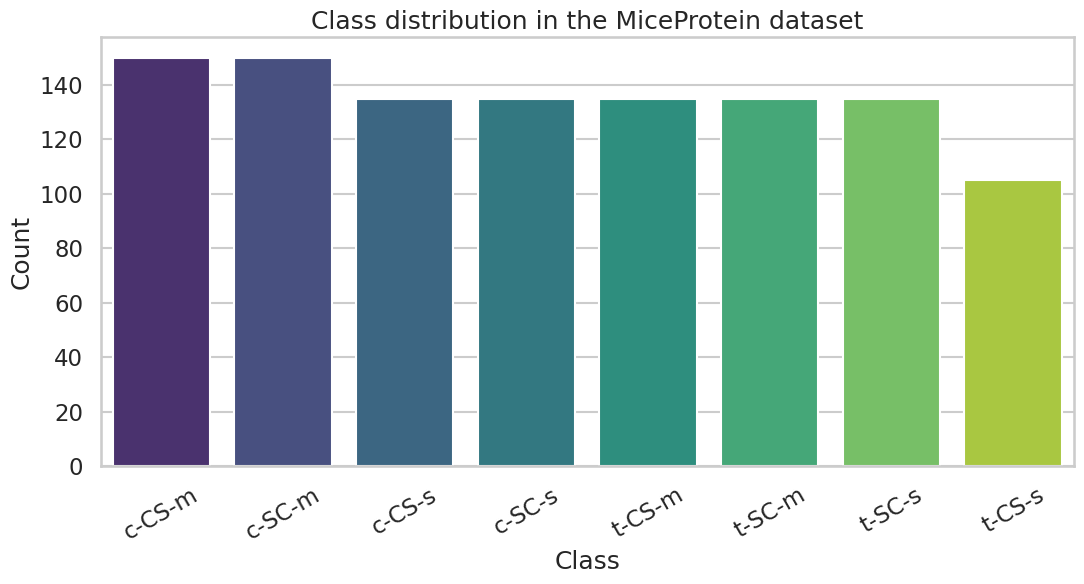

Saved table: genotype_treatment_behavior_counts.csv
Saved figure: stacked_counts_genotype_treatment_behavior.png / stacked_counts_genotype_treatment_behavior.pdf


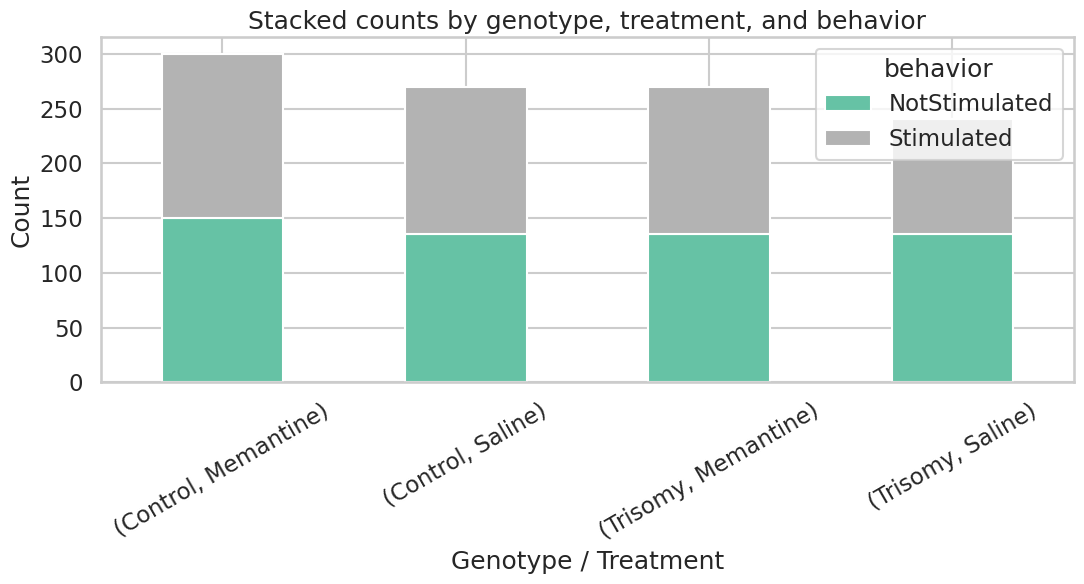

Saved figure: top_missingness_barplot.png / top_missingness_barplot.pdf


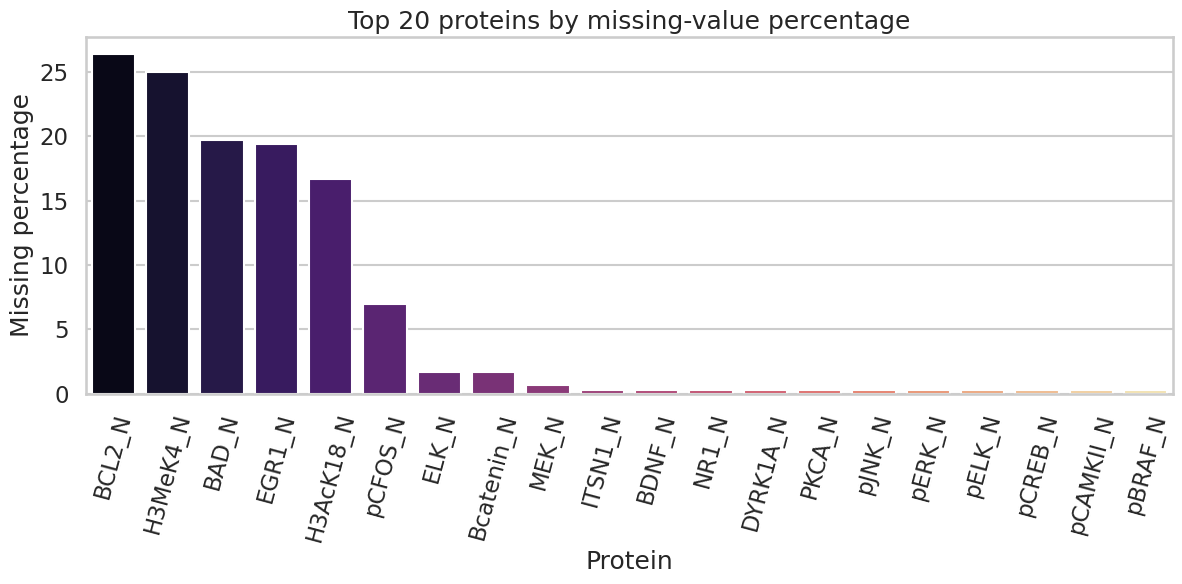

Saved table: pca_explained_variance.csv

PCA explained variance:


,PC,ExplainedVarianceRatio
0,PC1,0.253306
1,PC2,0.172844
2,PC3,0.102934
3,PC4,0.075140
4,PC5,0.049593
5,PC6,0.045884
6,PC7,0.035691
7,PC8,0.030582
8,PC9,0.023549
9,PC10,0.017036


Saved figure: pca_cumulative_variance.png / pca_cumulative_variance.pdf


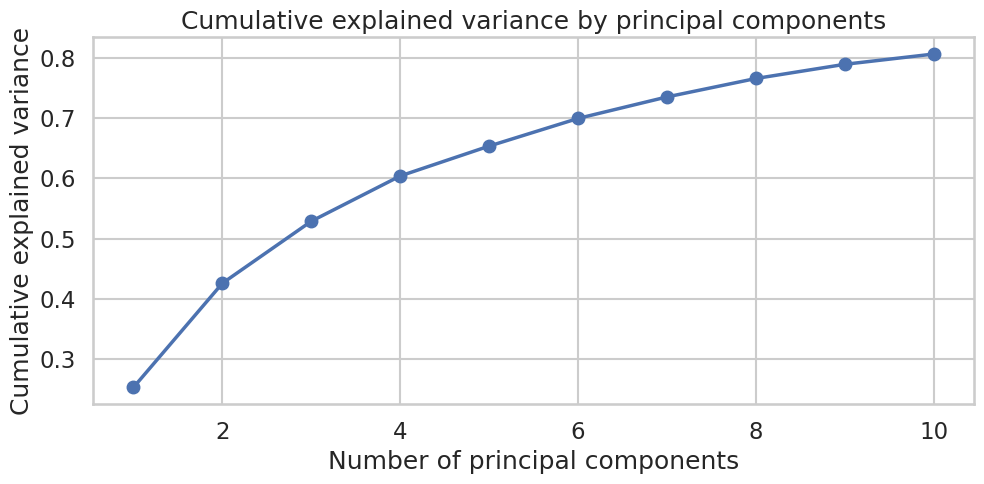

Saved figure: pca_scatter_genotype_treatment.png / pca_scatter_genotype_treatment.pdf


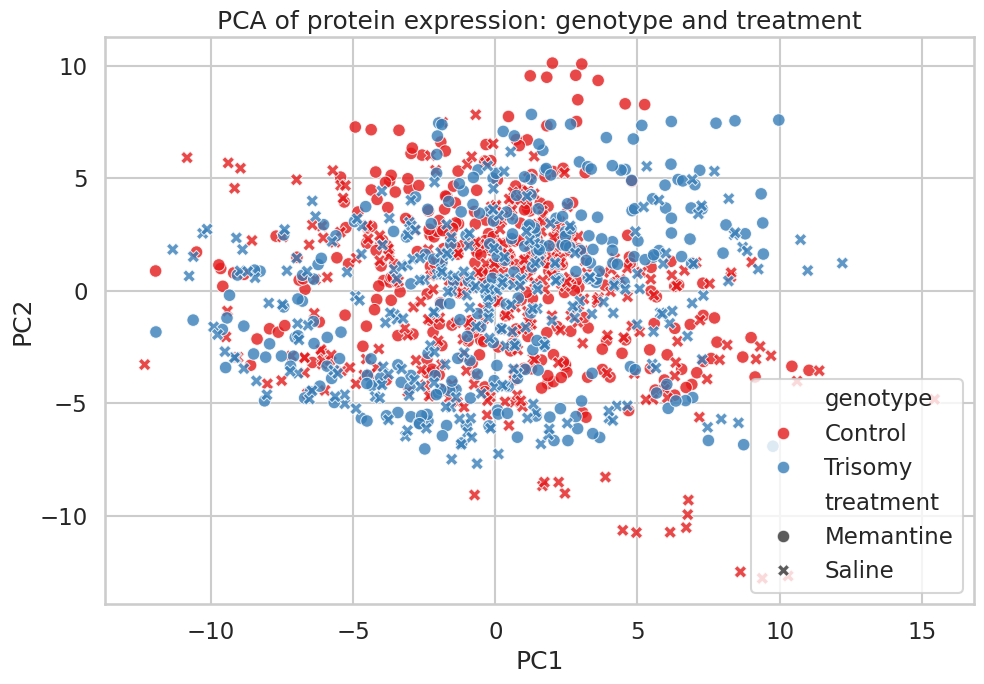

Saved figure: pca_scatter_by_class.png / pca_scatter_by_class.pdf


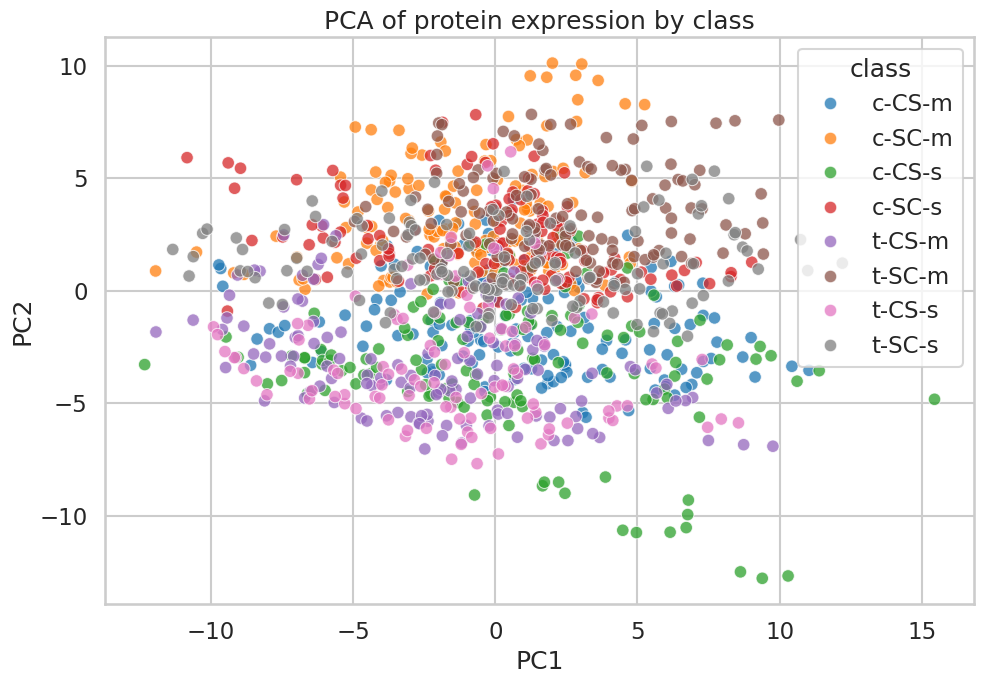

Saved figure: heatmap_top_variable_proteins.png / heatmap_top_variable_proteins.pdf


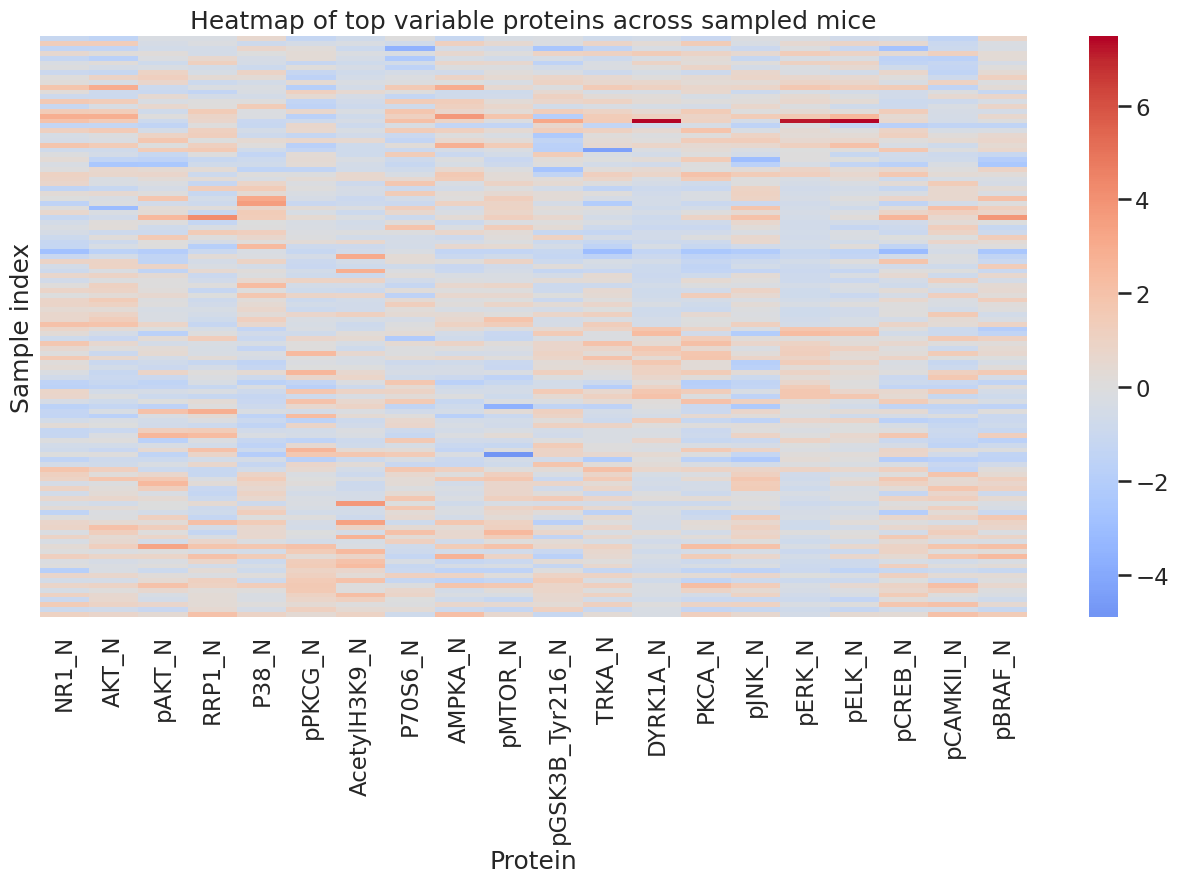

Saved table: top_reference_proteins_control_vs_trisomy.csv
Saved table: recovery_score_summary.csv

Recovery score summary:


,genotype,treatment,behavior,n,mean_recovery,sd_recovery,median_recovery
0,Control,Memantine,NotStimulated,150,-3.435074,0.938784,-3.411185
1,Control,Memantine,Stimulated,150,-3.805992,1.351506,-3.507259
2,Control,Saline,NotStimulated,135,-3.710021,1.983047,-3.117509
3,Control,Saline,Stimulated,135,-4.857924,2.801511,-3.749869
4,Trisomy,Memantine,NotStimulated,135,-3.744030,1.309161,-3.411898
5,Trisomy,Memantine,Stimulated,135,-4.692960,1.210828,-4.592622
6,Trisomy,Saline,NotStimulated,135,-4.937565,1.344120,-4.947457
7,Trisomy,Saline,Stimulated,105,-4.815443,1.514129,-4.503689


Saved figure: recovery_boxplot_genotype_treatment.png / recovery_boxplot_genotype_treatment.pdf


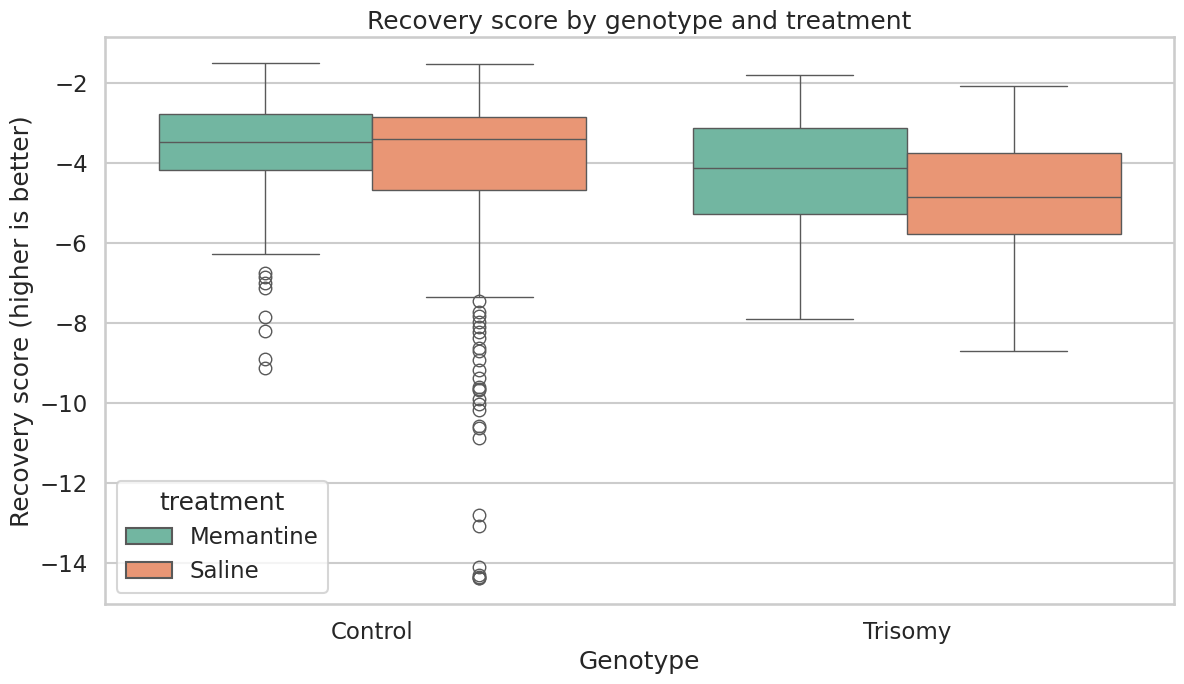

Saved figure: recovery_boxplot_behavior_treatment.png / recovery_boxplot_behavior_treatment.pdf


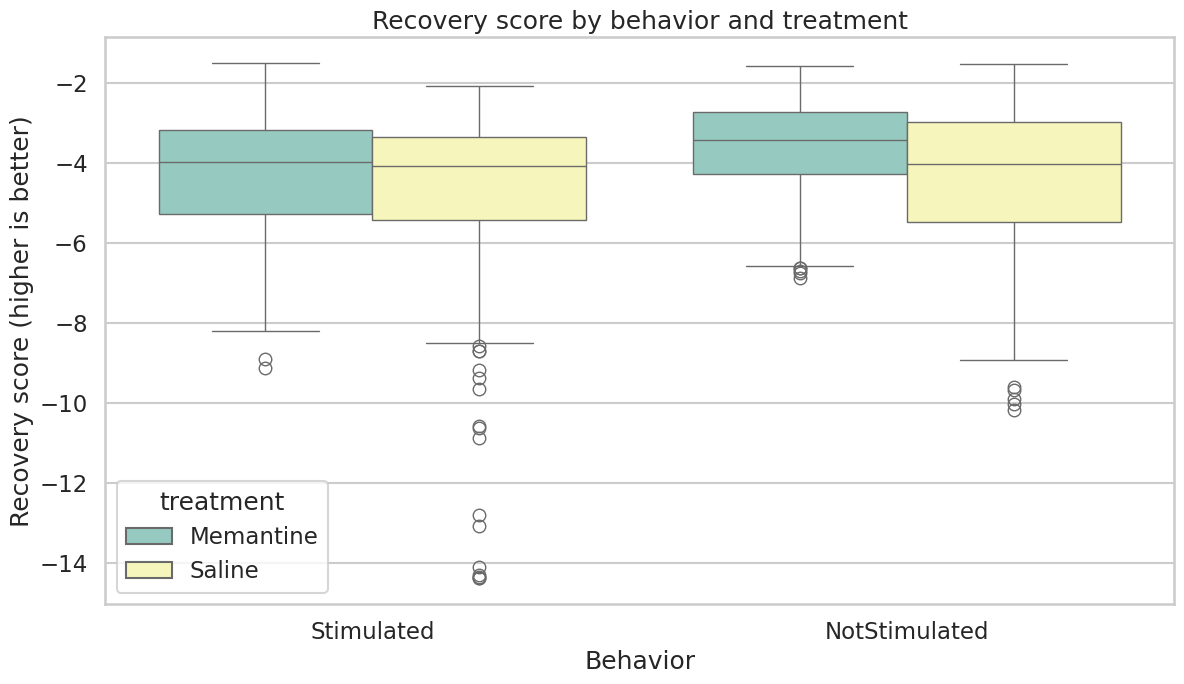

Saved figure: trisomy_recovery_violin_behavior_treatment.png / trisomy_recovery_violin_behavior_treatment.pdf


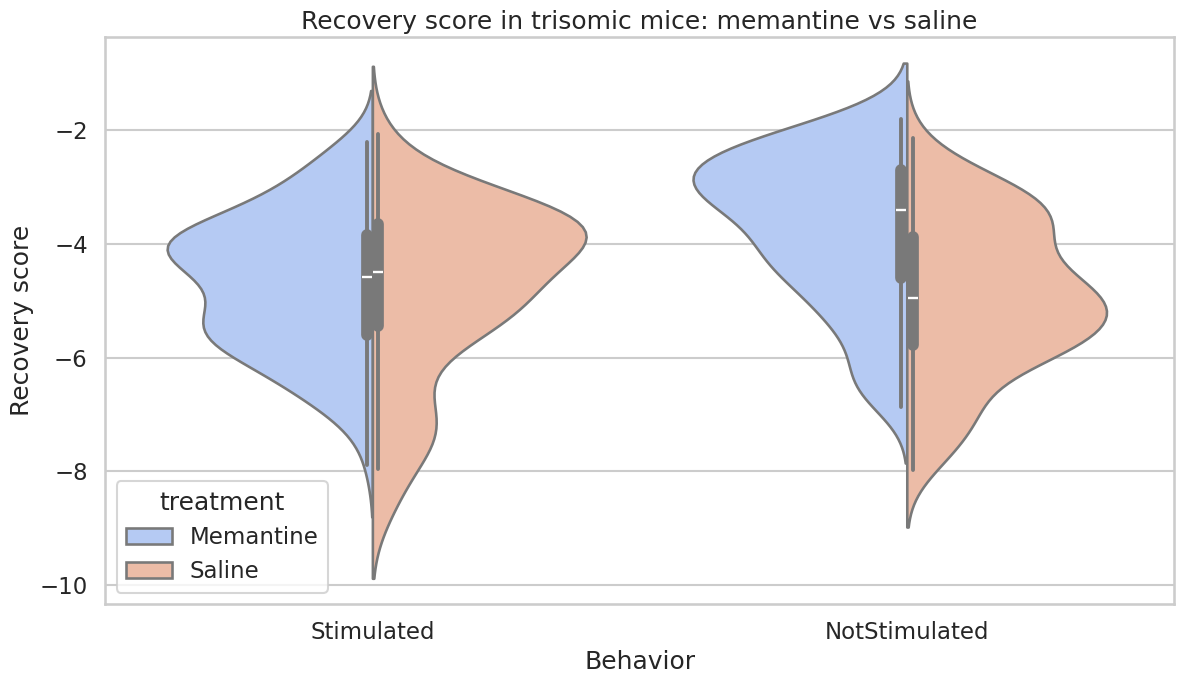

Saved table: subgroup_posterior_treatment_effects.csv

Subgroup posterior treatment effects (trisomic mice):


,Subgroup,n_memantine,n_saline,PosteriorMeanEffect_MemMinusSal,PosteriorSD,CI_low,CI_high,CredibleRiskScore,Recommendation
0,Stimulated,135,105,0.121941,0.180799,-0.232425,0.476307,0.013462,Memantine favored
1,NotStimulated,135,135,1.193349,0.161477,0.876854,1.509844,1.096463,Memantine favored


Saved figure: forest_subgroup_posterior_effects.png / forest_subgroup_posterior_effects.pdf


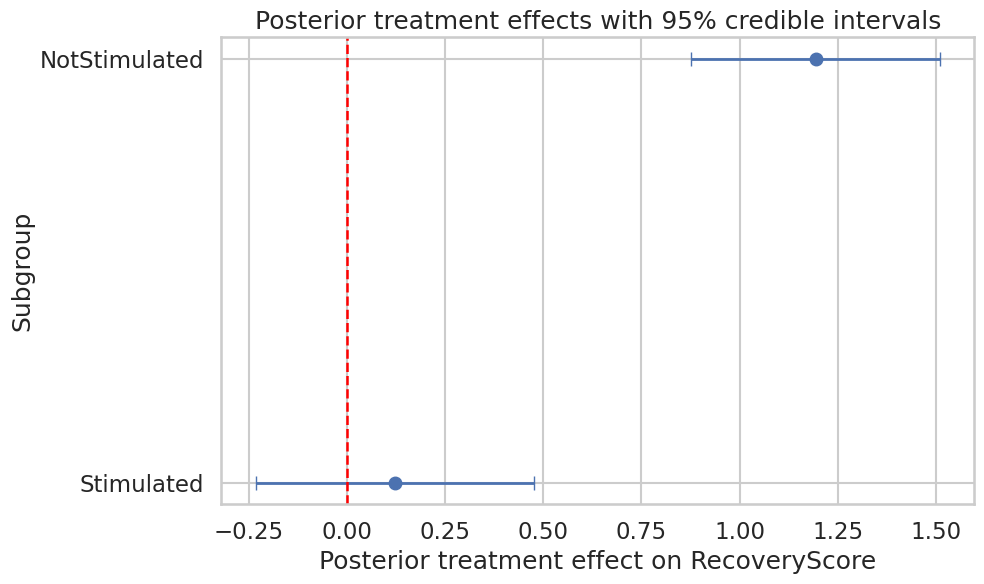

Saved table: sequential_posterior_learning_curve.csv
Saved figure: sequential_posterior_learning_curve.png / sequential_posterior_learning_curve.pdf


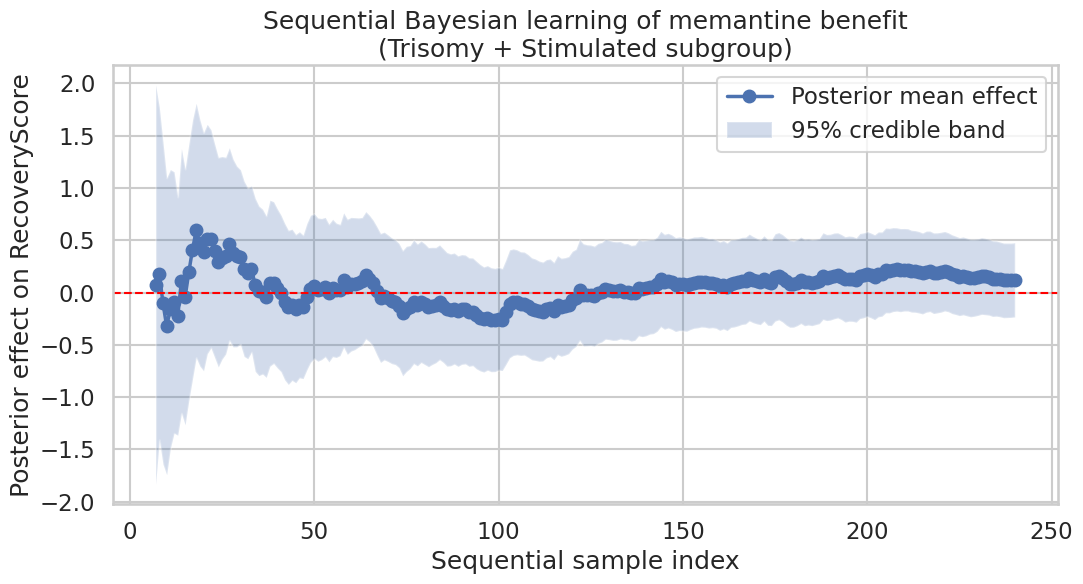

Saved figure: sequential_credible_risk_score.png / sequential_credible_risk_score.pdf


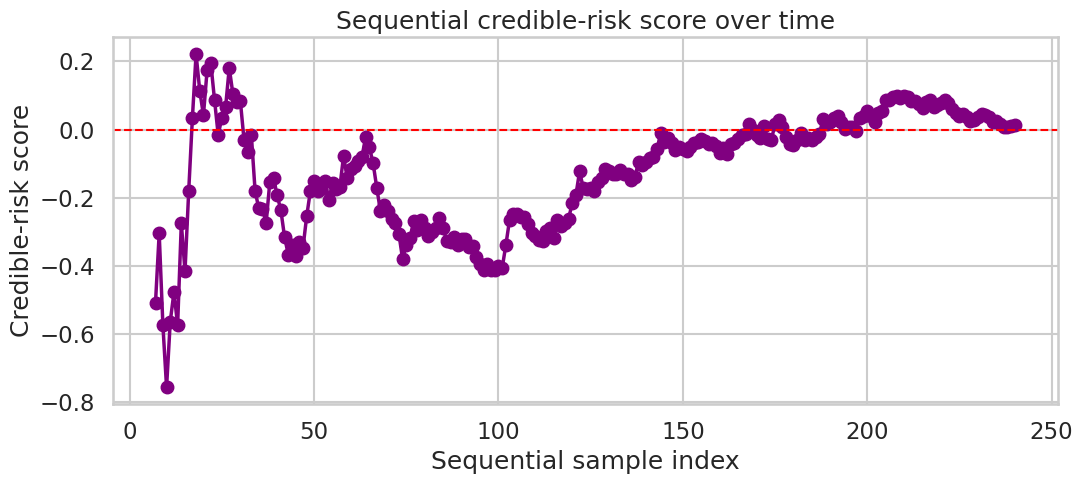

Saved table: latent_state_silhouette_scores.csv
Saved table: latent_state_counts.csv
Saved figure: latent_state_pca_scatter.png / latent_state_pca_scatter.pdf


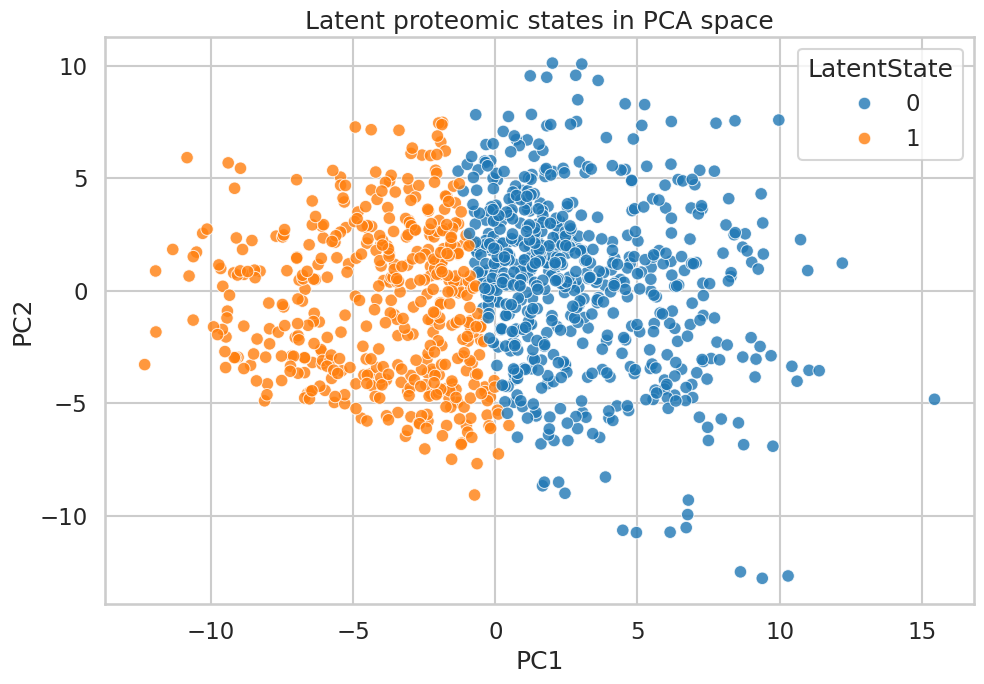

Saved table: latent_state_posterior_treatment_effects.csv

Latent-state posterior treatment effects:


,LatentState,n_memantine,n_saline,PosteriorMeanEffect_MemMinusSal,PosteriorSD,CI_low,CI_high,CredibleRiskScore,Recommendation
0,0,160,117,0.514216,0.162724,0.195276,0.833155,0.416581,Memantine favored
1,1,110,123,0.694650,0.172781,0.356001,1.033300,0.590982,Memantine favored


Saved figure: latent_state_effect_heatmap.png / latent_state_effect_heatmap.pdf


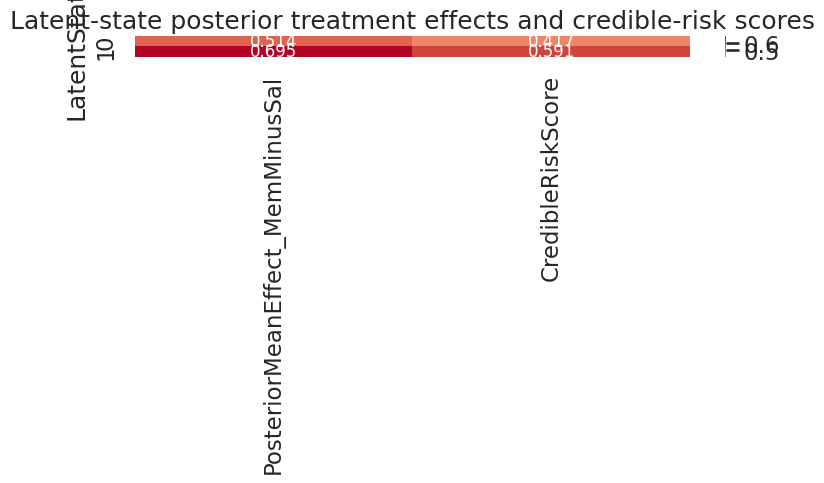

Saved table: protein_recovery_ranking.csv

Top proteins most improved toward control by memantine:


,protein,control_mean,trisomy_memantine_mean,trisomy_saline_mean,improvement_toward_control,ci_low,ci_high
0,pPKCG_N,1.556958,1.633573,2.144149,0.510575,0.411366,0.602557
1,NR2A_N,3.984687,3.811091,3.541280,0.269812,0.101928,0.421698
2,S6_N,0.384658,0.423164,0.541893,0.118728,0.094859,0.138607
3,pNR2B_N,1.593348,1.575073,1.471052,0.104021,0.055307,0.143322
4,pMTOR_N,0.779222,0.773119,0.694966,0.078153,0.053992,0.097779
5,pELK_N,1.443155,1.472710,1.342200,0.071398,-0.027822,0.149078
6,NR1_N,2.333654,2.287993,2.220677,0.067317,0.010702,0.122531
7,pPKCAB_N,1.515931,1.447064,1.635227,0.050429,-0.054353,0.162039
8,pP70S6_N,0.368693,0.400607,0.450766,0.050160,0.019573,0.082486
9,P38_N,0.429879,0.420917,0.374323,0.046593,0.031280,0.059547


Saved figure: top_protein_recovery_forest.png / top_protein_recovery_forest.pdf


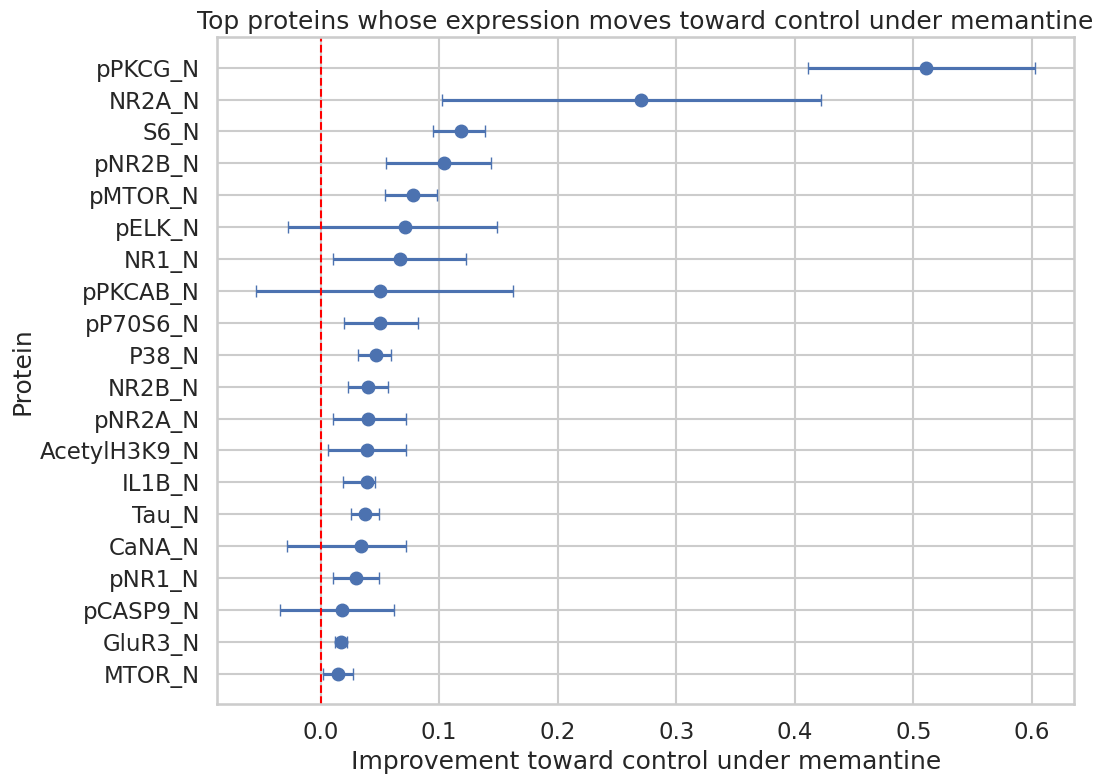

Saved table: correlation_top_recovery_proteins.csv
Saved figure: correlation_heatmap_top_recovery_proteins.png / correlation_heatmap_top_recovery_proteins.pdf


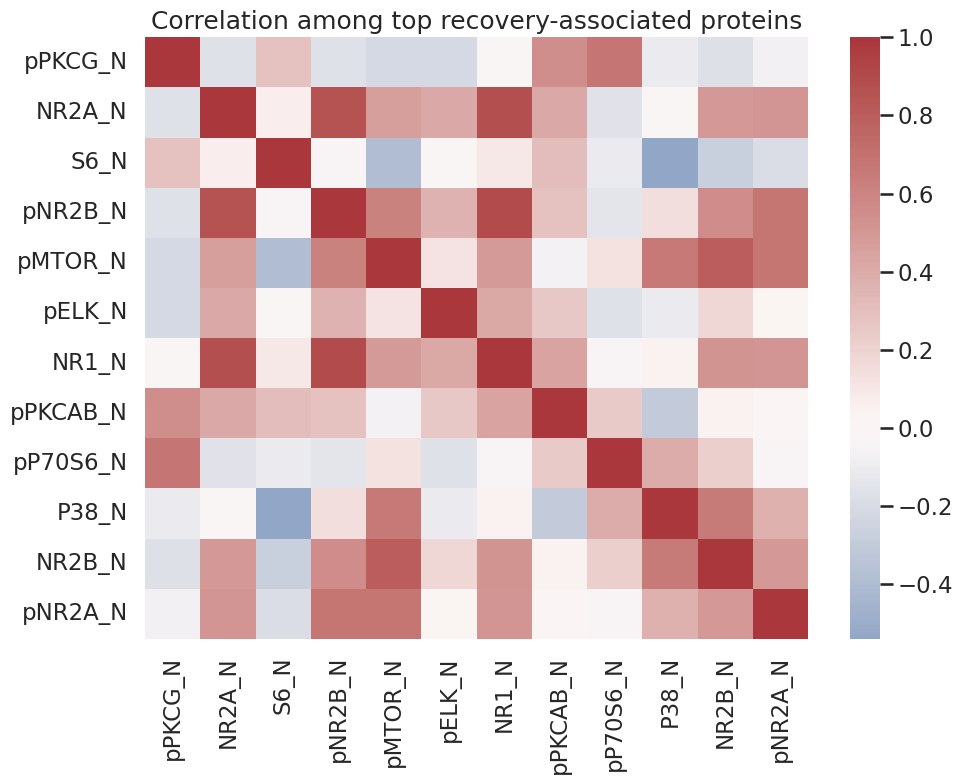

Saved table: global_treatment_effects.csv

Global treatment effects:


,Group,n_memantine,n_saline,PosteriorMeanEffect_MemMinusSal,PosteriorSD,PosteriorCI_low,PosteriorCI_high,BootstrapMeanDiff,BootstrapCI_low,BootstrapCI_high,CredibleRiskScore
0,Control,300,270,0.662623,0.166035,0.337194,0.988052,0.671676,0.350116,1.004773,0.563002
1,Trisomy,270,240,0.665514,0.122863,0.424702,0.906326,0.664917,0.426653,0.922805,0.591796


Saved figure: global_posterior_treatment_effect_barplot.png / global_posterior_treatment_effect_barplot.pdf


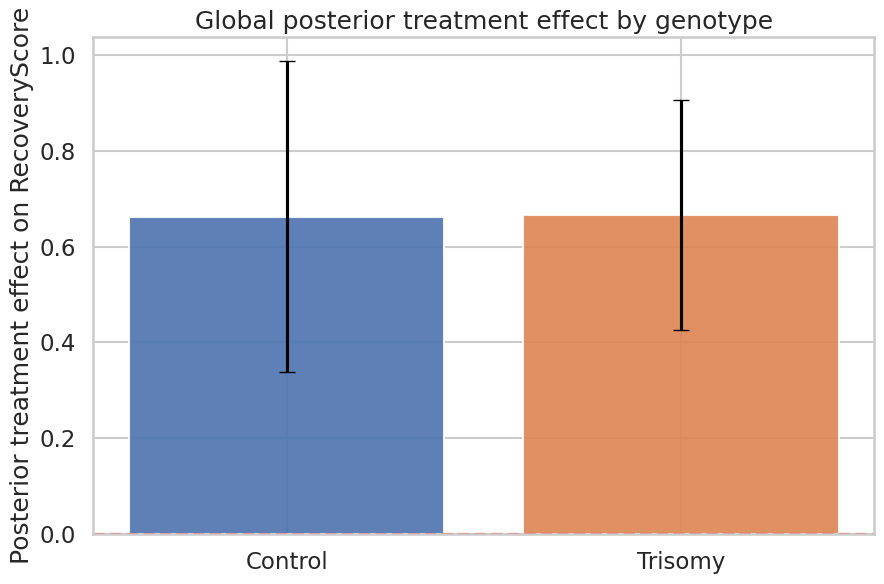

Saved table: publication_style_subgroup_results.csv

ZIP file created: /content/bayesian_game_realdata_outputs.zip

Key tables shown inline:

1) Subgroup posterior treatment effects


,Subgroup,n_memantine,n_saline,PosteriorMeanEffect_MemMinusSal,PosteriorSD,CI_low,CI_high,CredibleRiskScore,Recommendation
0,Stimulated,135,105,0.121941,0.180799,-0.232425,0.476307,0.013462,Memantine favored
1,NotStimulated,135,135,1.193349,0.161477,0.876854,1.509844,1.096463,Memantine favored



2) Latent-state posterior treatment effects


,LatentState,n_memantine,n_saline,PosteriorMeanEffect_MemMinusSal,PosteriorSD,CI_low,CI_high,CredibleRiskScore,Recommendation
0,0,160,117,0.514216,0.162724,0.195276,0.833155,0.416581,Memantine favored
1,1,110,123,0.694650,0.172781,0.356001,1.033300,0.590982,Memantine favored



3) Top recovery-associated proteins


,protein,control_mean,trisomy_memantine_mean,trisomy_saline_mean,improvement_toward_control,ci_low,ci_high
0,pPKCG_N,1.556958,1.633573,2.144149,0.510575,0.411366,0.602557
1,NR2A_N,3.984687,3.811091,3.541280,0.269812,0.101928,0.421698
2,S6_N,0.384658,0.423164,0.541893,0.118728,0.094859,0.138607
3,pNR2B_N,1.593348,1.575073,1.471052,0.104021,0.055307,0.143322
4,pMTOR_N,0.779222,0.773119,0.694966,0.078153,0.053992,0.097779
5,pELK_N,1.443155,1.472710,1.342200,0.071398,-0.027822,0.149078
6,NR1_N,2.333654,2.287993,2.220677,0.067317,0.010702,0.122531
7,pPKCAB_N,1.515931,1.447064,1.635227,0.050429,-0.054353,0.162039
8,pP70S6_N,0.368693,0.400607,0.450766,0.050160,0.019573,0.082486
9,P38_N,0.429879,0.420917,0.374323,0.046593,0.031280,0.059547



4) Global treatment effects


,Group,n_memantine,n_saline,PosteriorMeanEffect_MemMinusSal,PosteriorSD,PosteriorCI_low,PosteriorCI_high,BootstrapMeanDiff,BootstrapCI_low,BootstrapCI_high,CredibleRiskScore
0,Control,300,270,0.662623,0.166035,0.337194,0.988052,0.671676,0.350116,1.004773,0.563002
1,Trisomy,270,240,0.665514,0.122863,0.424702,0.906326,0.664917,0.426653,0.922805,0.591796



To download automatically in Colab, run:
files.download('bayesian_game_realdata_outputs.zip')

Done.


In [3]:
# ============================================================
# GOOGLE COLAB COPY-PASTEABLE PYTHON SCRIPT
# Real-data empirical illustration for the proposed
# Bayesian credible-risk methodology on MiceProtein
# ============================================================

# This script:
# 1. Loads the real MiceProtein proteomic dataset from OpenML
# 2. Performs careful preprocessing and exploratory analysis
# 3. Constructs a "healthy-reference recovery score"
# 4. Applies the proposed Bayesian credible-risk decision idea
#    to treatment-benefit analysis in trisomic mice
# 5. Performs subgroup and latent-state posterior analyses
# 6. Produces colorful plots and tables
# 7. Saves everything and zips all outputs automatically
#
# ------------------------------------------------------------
# IMPORTANT:
# - Designed for Google Colab
# - Requires internet access for fetch_openml
# - No model-comparison section is included, per your request
# ------------------------------------------------------------

# ============================================================
# 0. Imports
# ============================================================
import os
import json
import math
import time
import zipfile
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from IPython.display import display

warnings.filterwarnings("ignore")

# ============================================================
# 1. Global setup
# ============================================================
GLOBAL_SEED = 20260306
rng = np.random.default_rng(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12

BASE_DIR = Path.cwd() / "bayesian_game_realdata_outputs"
FIG_DIR = BASE_DIR / "figures"
TAB_DIR = BASE_DIR / "tables"
RAW_DIR = BASE_DIR / "raw_data"

for d in [BASE_DIR, FIG_DIR, TAB_DIR, RAW_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Output directory:", BASE_DIR.resolve())

# ============================================================
# 2. Helper functions
# ============================================================
def savefig(name, dpi=220):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=dpi, bbox_inches="tight")
    plt.savefig(FIG_DIR / f"{name}.pdf", dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {name}.png / {name}.pdf")

def save_table(df, name):
    csv_path = TAB_DIR / f"{name}.csv"
    xlsx_path = TAB_DIR / f"{name}.xlsx"
    df.to_csv(csv_path, index=False)
    try:
        df.to_excel(xlsx_path, index=False)
    except Exception as e:
        print(f"Excel export skipped for {name}: {e}")
    print(f"Saved table: {name}.csv")

def posterior_mean_sd_normal(data, mu0=0.0, tau0_sq=100.0):
    """
    Conjugate Normal-Normal posterior for the mean with known variance
    approximated using sample variance.
    """
    y = np.asarray(data, dtype=float)
    y = y[np.isfinite(y)]
    n = len(y)
    if n == 0:
        return np.nan, np.nan, np.nan, np.nan

    sample_mean = np.mean(y)
    sample_var = np.var(y, ddof=1) if n > 1 else 1.0
    sigma_sq = max(sample_var, 1e-6)

    prec_post = 1.0 / tau0_sq + n / sigma_sq
    var_post = 1.0 / prec_post
    mean_post = var_post * (mu0 / tau0_sq + n * sample_mean / sigma_sq)
    sd_post = np.sqrt(var_post)

    lo = mean_post - 1.96 * sd_post
    hi = mean_post + 1.96 * sd_post
    return mean_post, sd_post, lo, hi

def posterior_treatment_effect(y_treat, y_control, mu0=0.0, tau0_sq=100.0):
    """
    Approximate posterior for difference in means:
      Delta = mean(treat) - mean(control)
    using independent Normal posteriors for subgroup means.
    """
    mt, sdt, lot, hit = posterior_mean_sd_normal(y_treat, mu0=mu0, tau0_sq=tau0_sq)
    mc, sdc, loc, hic = posterior_mean_sd_normal(y_control, mu0=mu0, tau0_sq=tau0_sq)

    if np.isnan(mt) or np.isnan(mc):
        return {
            "post_mean": np.nan,
            "post_sd": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan
        }

    mean_delta = mt - mc
    sd_delta = np.sqrt(sdt**2 + sdc**2)
    lo = mean_delta - 1.96 * sd_delta
    hi = mean_delta + 1.96 * sd_delta

    return {
        "post_mean": mean_delta,
        "post_sd": sd_delta,
        "ci_low": lo,
        "ci_high": hi
    }

def credible_risk_score(post_mean, post_sd, kappa=0.60):
    if np.isnan(post_mean) or np.isnan(post_sd):
        return np.nan
    return post_mean - kappa * post_sd

def bootstrap_ci_mean_diff(x, y, B=2000, seed=123):
    rr = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    diffs = np.zeros(B)
    for b in range(B):
        xb = rr.choice(x, size=len(x), replace=True)
        yb = rr.choice(y, size=len(y), replace=True)
        diffs[b] = np.mean(xb) - np.mean(yb)

    mean_diff = np.mean(diffs)
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    return mean_diff, lo, hi

def safe_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return np.nan
    return np.std(x, ddof=1)

# ============================================================
# 3. Configuration
# ============================================================
@dataclass
class Config:
    openml_data_id: int = 40966
    top_var_proteins_heatmap: int = 20
    n_heatmap_samples_per_class: int = 15
    n_top_reference_proteins: int = 20
    latent_states_k: int = 4
    kappa: float = 0.60
    n_bootstrap: int = 1500
    random_state: int = GLOBAL_SEED
    n_top_proteins_ranked: int = 20

cfg = Config()

# ============================================================
# 4. Load real data
# ============================================================
print("\nLoading MiceProtein from OpenML via scikit-learn...")
mice = fetch_openml(data_id=cfg.openml_data_id, as_frame=True)

X = mice.data.copy()
y = pd.Series(mice.target, name="class").astype(str)

print("Raw feature matrix shape:", X.shape)
print("Number of target labels:", y.shape[0])

# Save raw meta
meta = {
    "openml_name": mice.details.get("name", "unknown"),
    "openml_id": mice.details.get("id", "unknown"),
    "version": mice.details.get("version", "unknown"),
    "url": getattr(mice, "url", None),
    "n_samples": int(X.shape[0]),
    "n_features": int(X.shape[1]),
}
with open(RAW_DIR / "dataset_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

# ============================================================
# 5. Parse class labels
# ============================================================
# Class examples:
# c-CS-s, c-CS-m, c-SC-s, c-SC-m, t-CS-s, t-CS-m, t-SC-s, t-SC-m

df = X.copy()
df["class"] = y.values

parts = df["class"].str.split("-", expand=True)
df["genotype_code"] = parts[0]
df["behavior_code"] = parts[1]
df["treatment_code"] = parts[2]

df["genotype"] = df["genotype_code"].map({"c": "Control", "t": "Trisomy"})
df["behavior"] = df["behavior_code"].map({"CS": "Stimulated", "SC": "NotStimulated"})
df["treatment"] = df["treatment_code"].map({"m": "Memantine", "s": "Saline"})

protein_cols = [c for c in X.columns if c not in ["class"]]

print("\nParsed data head:")
display(df[["class", "genotype", "behavior", "treatment"]].head())

# ============================================================
# 6. Missingness analysis and imputation
# ============================================================
missing_summary = pd.DataFrame({
    "protein": protein_cols,
    "missing_count": [df[c].isna().sum() for c in protein_cols],
    "missing_pct": [100 * df[c].isna().mean() for c in protein_cols]
}).sort_values("missing_pct", ascending=False).reset_index(drop=True)

save_table(missing_summary, "missingness_summary")

# Classwise median imputation
df_imp = df.copy()
for col in protein_cols:
    df_imp[col] = pd.to_numeric(df_imp[col], errors="coerce")
    df_imp[col] = df_imp.groupby("class")[col].transform(lambda s: s.fillna(s.median()))
    df_imp[col] = df_imp[col].fillna(df_imp[col].median())

# Sanity check
assert df_imp[protein_cols].isna().sum().sum() == 0, "Imputation failed: missing values remain"

print("\nMissing values after imputation:", int(df_imp[protein_cols].isna().sum().sum()))

# Save cleaned dataset
df_imp.to_csv(RAW_DIR / "miceprotein_cleaned.csv", index=False)

# ============================================================
# 7. Dataset summary table
# ============================================================
dataset_summary = pd.DataFrame({
    "Quantity": [
        "Number of samples",
        "Number of protein features",
        "Number of classes",
        "Number of Control samples",
        "Number of Trisomy samples",
        "Number of Memantine samples",
        "Number of Saline samples",
        "Number of Stimulated samples",
        "Number of NotStimulated samples"
    ],
    "Value": [
        df_imp.shape[0],
        len(protein_cols),
        df_imp["class"].nunique(),
        (df_imp["genotype"] == "Control").sum(),
        (df_imp["genotype"] == "Trisomy").sum(),
        (df_imp["treatment"] == "Memantine").sum(),
        (df_imp["treatment"] == "Saline").sum(),
        (df_imp["behavior"] == "Stimulated").sum(),
        (df_imp["behavior"] == "NotStimulated").sum(),
    ]
})
save_table(dataset_summary, "dataset_summary")
print("\nDataset summary:")
display(dataset_summary)

# ============================================================
# 8. Exploratory plots
# ============================================================

# 8.1 Class counts
class_counts = df_imp["class"].value_counts().rename_axis("class").reset_index(name="count")
save_table(class_counts, "class_counts")

plt.figure(figsize=(11, 6))
sns.barplot(data=class_counts, x="class", y="count", palette="viridis")
plt.title("Class distribution in the MiceProtein dataset")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=30)
savefig("class_distribution")
plt.show()

# 8.2 Stacked bar by genotype x treatment x behavior
combo_counts = (
    df_imp.groupby(["genotype", "treatment", "behavior"])
    .size()
    .reset_index(name="count")
)
save_table(combo_counts, "genotype_treatment_behavior_counts")

pivot_combo = combo_counts.pivot_table(index=["genotype", "treatment"], columns="behavior", values="count", fill_value=0)
pivot_combo.plot(kind="bar", stacked=True, figsize=(11, 6), colormap="Set2")
plt.title("Stacked counts by genotype, treatment, and behavior")
plt.xlabel("Genotype / Treatment")
plt.ylabel("Count")
plt.xticks(rotation=30)
savefig("stacked_counts_genotype_treatment_behavior")
plt.show()

# 8.3 Missingness bar
top_missing = missing_summary.head(20)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_missing, x="protein", y="missing_pct", palette="magma")
plt.title("Top 20 proteins by missing-value percentage")
plt.xlabel("Protein")
plt.ylabel("Missing percentage")
plt.xticks(rotation=75)
savefig("top_missingness_barplot")
plt.show()

# ============================================================
# 9. Standardization and PCA
# ============================================================
X_num = df_imp[protein_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

pca = PCA(n_components=10, random_state=cfg.random_state)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca[:, :4], columns=["PC1", "PC2", "PC3", "PC4"])
pca_df = pd.concat([pca_df, df_imp[["class", "genotype", "behavior", "treatment"]].reset_index(drop=True)], axis=1)

explained_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "ExplainedVarianceRatio": pca.explained_variance_ratio_
})
save_table(explained_variance, "pca_explained_variance")

print("\nPCA explained variance:")
display(explained_variance.head(10))

# PCA scree plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_),
         marker="o", linewidth=2.5)
plt.title("Cumulative explained variance by principal components")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
savefig("pca_cumulative_variance")
plt.show()

# PCA scatter by genotype
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="genotype", style="treatment", palette="Set1", alpha=0.8)
plt.title("PCA of protein expression: genotype and treatment")
savefig("pca_scatter_genotype_treatment")
plt.show()

# PCA scatter by class
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="class", palette="tab10", alpha=0.75)
plt.title("PCA of protein expression by class")
savefig("pca_scatter_by_class")
plt.show()

# ============================================================
# 10. Heatmap of top variable proteins
# ============================================================
protein_variances = pd.Series(X_scaled.var(axis=0), index=protein_cols).sort_values(ascending=False)
top_var_proteins = protein_variances.head(cfg.top_var_proteins_heatmap).index.tolist()

heat_df = df_imp.copy()
sampled_idx = (
    heat_df.groupby("class", group_keys=False)
    .apply(lambda s: s.sample(min(cfg.n_heatmap_samples_per_class, len(s)), random_state=cfg.random_state))
    .index
)
heat_sample = heat_df.loc[sampled_idx, top_var_proteins + ["class"]].copy()
heat_sample = heat_sample.sort_values("class").reset_index(drop=True)

heat_matrix = heat_sample[top_var_proteins].values
heat_matrix = StandardScaler().fit_transform(heat_matrix)

plt.figure(figsize=(13, 9))
sns.heatmap(heat_matrix, cmap="coolwarm", center=0,
            xticklabels=top_var_proteins, yticklabels=False)
plt.title("Heatmap of top variable proteins across sampled mice")
plt.xlabel("Protein")
plt.ylabel("Sample index")
savefig("heatmap_top_variable_proteins")
plt.show()

# ============================================================
# 11. Construct a healthy-reference recovery score
# ============================================================
# Idea:
# - Use Control mice as biological "healthy reference"
# - Select proteins most different between Control and Trisomy
# - Compute standardized distance from each sample to the Control centroid
# - Define RecoveryScore = negative distance (higher is better)

control_mask = df_imp["genotype"] == "Control"
trisomy_mask = df_imp["genotype"] == "Trisomy"

control_mean = df_imp.loc[control_mask, protein_cols].mean()
trisomy_mean = df_imp.loc[trisomy_mask, protein_cols].mean()
delta_abs = (control_mean - trisomy_mean).abs().sort_values(ascending=False)
reference_proteins = delta_abs.head(cfg.n_top_reference_proteins).index.tolist()

save_table(
    pd.DataFrame({
        "protein": delta_abs.index,
        "absolute_mean_difference_control_vs_trisomy": delta_abs.values
    }).head(30),
    "top_reference_proteins_control_vs_trisomy"
)

# Standardize selected proteins
X_ref = df_imp[reference_proteins].copy()
scaler_ref = StandardScaler()
X_ref_scaled = scaler_ref.fit_transform(X_ref)

ref_df = pd.DataFrame(X_ref_scaled, columns=reference_proteins)
ref_df = pd.concat([ref_df, df_imp[["class", "genotype", "behavior", "treatment"]].reset_index(drop=True)], axis=1)

control_centroid = ref_df.loc[ref_df["genotype"] == "Control", reference_proteins].mean().values.reshape(1, -1)
all_points = ref_df[reference_proteins].values
dist_to_control = cdist(all_points, control_centroid, metric="euclidean").ravel()

df_imp["RecoveryScore"] = -dist_to_control  # higher = closer to control centroid = better biological recovery
df_imp["AbsDistanceToControl"] = dist_to_control

recovery_summary = (
    df_imp.groupby(["genotype", "treatment", "behavior"], as_index=False)
    .agg(
        n=("RecoveryScore", "size"),
        mean_recovery=("RecoveryScore", "mean"),
        sd_recovery=("RecoveryScore", safe_std),
        median_recovery=("RecoveryScore", "median")
    )
)
save_table(recovery_summary, "recovery_score_summary")
print("\nRecovery score summary:")
display(recovery_summary)

# Plot RecoveryScore by groups
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_imp, x="genotype", y="RecoveryScore", hue="treatment", palette="Set2")
plt.title("Recovery score by genotype and treatment")
plt.xlabel("Genotype")
plt.ylabel("Recovery score (higher is better)")
savefig("recovery_boxplot_genotype_treatment")
plt.show()

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_imp, x="behavior", y="RecoveryScore", hue="treatment", palette="Set3")
plt.title("Recovery score by behavior and treatment")
plt.xlabel("Behavior")
plt.ylabel("Recovery score (higher is better)")
savefig("recovery_boxplot_behavior_treatment")
plt.show()

plt.figure(figsize=(12, 7))
sns.violinplot(data=df_imp[df_imp["genotype"] == "Trisomy"], x="behavior", y="RecoveryScore", hue="treatment",
               split=True, palette="coolwarm")
plt.title("Recovery score in trisomic mice: memantine vs saline")
plt.xlabel("Behavior")
plt.ylabel("Recovery score")
savefig("trisomy_recovery_violin_behavior_treatment")
plt.show()

# ============================================================
# 12. Proposed Bayesian credible-risk subgroup analysis
# ============================================================
# Focus on trisomic mice: does memantine improve RecoveryScore?
# Decision score = posterior mean treatment effect - kappa * posterior sd

tris_df = df_imp[df_imp["genotype"] == "Trisomy"].copy()

subgroup_rows = []
for beh in ["Stimulated", "NotStimulated"]:
    sub = tris_df[tris_df["behavior"] == beh].copy()
    y_mem = sub.loc[sub["treatment"] == "Memantine", "RecoveryScore"].values
    y_sal = sub.loc[sub["treatment"] == "Saline", "RecoveryScore"].values

    out = posterior_treatment_effect(y_mem, y_sal, mu0=0.0, tau0_sq=100.0)
    crs = credible_risk_score(out["post_mean"], out["post_sd"], kappa=cfg.kappa)

    subgroup_rows.append({
        "Subgroup": beh,
        "n_memantine": len(y_mem),
        "n_saline": len(y_sal),
        "PosteriorMeanEffect_MemMinusSal": out["post_mean"],
        "PosteriorSD": out["post_sd"],
        "CI_low": out["ci_low"],
        "CI_high": out["ci_high"],
        "CredibleRiskScore": crs,
        "Recommendation": "Memantine favored" if crs > 0 else "Conservative / no clear advantage"
    })

subgroup_results = pd.DataFrame(subgroup_rows)
save_table(subgroup_results, "subgroup_posterior_treatment_effects")
print("\nSubgroup posterior treatment effects (trisomic mice):")
display(subgroup_results)

# Forest plot
forest_df = subgroup_results.copy()
forest_df = forest_df.sort_values("PosteriorMeanEffect_MemMinusSal")

plt.figure(figsize=(10, 6))
plt.errorbar(
    x=forest_df["PosteriorMeanEffect_MemMinusSal"],
    y=np.arange(len(forest_df)),
    xerr=1.96 * forest_df["PosteriorSD"],
    fmt="o",
    capsize=5,
    linewidth=2
)
plt.axvline(0, color="red", linestyle="--", linewidth=1.8)
plt.yticks(np.arange(len(forest_df)), forest_df["Subgroup"])
plt.xlabel("Posterior treatment effect on RecoveryScore")
plt.ylabel("Subgroup")
plt.title("Posterior treatment effects with 95% credible intervals")
savefig("forest_subgroup_posterior_effects")
plt.show()

# ============================================================
# 13. Sequential Bayesian learning curve
# ============================================================
# Pseudo-online analysis:
# We process trisomic-stimulated mice in random order and update the
# posterior treatment effect after each new observation.
#
# This is the real-data analogue of your proposal's learning component.

seq_df = tris_df[tris_df["behavior"] == "Stimulated"].copy().sample(frac=1, random_state=cfg.random_state).reset_index(drop=True)

seen_mem = []
seen_sal = []
seq_rows = []

for i in range(len(seq_df)):
    row = seq_df.iloc[i]
    if row["treatment"] == "Memantine":
        seen_mem.append(row["RecoveryScore"])
    else:
        seen_sal.append(row["RecoveryScore"])

    if len(seen_mem) >= 3 and len(seen_sal) >= 3:
        out = posterior_treatment_effect(seen_mem, seen_sal, mu0=0.0, tau0_sq=100.0)
        crs = credible_risk_score(out["post_mean"], out["post_sd"], kappa=cfg.kappa)

        seq_rows.append({
            "step": i + 1,
            "n_mem": len(seen_mem),
            "n_sal": len(seen_sal),
            "post_mean_effect": out["post_mean"],
            "post_sd": out["post_sd"],
            "ci_low": out["ci_low"],
            "ci_high": out["ci_high"],
            "credible_risk_score": crs,
            "recommend_memantine": 1 if crs > 0 else 0
        })

seq_results = pd.DataFrame(seq_rows)
save_table(seq_results, "sequential_posterior_learning_curve")

if len(seq_results) > 0:
    plt.figure(figsize=(11, 6))
    plt.plot(seq_results["step"], seq_results["post_mean_effect"], marker="o", linewidth=2.5, label="Posterior mean effect")
    plt.fill_between(seq_results["step"], seq_results["ci_low"], seq_results["ci_high"], alpha=0.25, label="95% credible band")
    plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
    plt.title("Sequential Bayesian learning of memantine benefit\n(Trisomy + Stimulated subgroup)")
    plt.xlabel("Sequential sample index")
    plt.ylabel("Posterior effect on RecoveryScore")
    plt.legend()
    savefig("sequential_posterior_learning_curve")
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(seq_results["step"], seq_results["credible_risk_score"], marker="o", linewidth=2.5, color="purple")
    plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
    plt.title("Sequential credible-risk score over time")
    plt.xlabel("Sequential sample index")
    plt.ylabel("Credible-risk score")
    savefig("sequential_credible_risk_score")
    plt.show()

# ============================================================
# 14. Latent-state empirical analysis
# ============================================================
# A "top-statistics-paper" style addition:
# infer latent proteomic states using PCA + k-means,
# then study posterior treatment effects within states.

pca_for_cluster = X_pca[:, :6]

best_k = cfg.latent_states_k
# Optional silhouette scoring around the requested K
sil_rows = []
for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=cfg.random_state, n_init=20)
    labels = km.fit_predict(pca_for_cluster)
    sil = silhouette_score(pca_for_cluster, labels)
    sil_rows.append({"k": k, "silhouette_score": sil})
silhouette_df = pd.DataFrame(sil_rows)
save_table(silhouette_df, "latent_state_silhouette_scores")

best_k = int(silhouette_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
km = KMeans(n_clusters=best_k, random_state=cfg.random_state, n_init=20)
df_imp["LatentState"] = km.fit_predict(pca_for_cluster).astype(int)

latent_counts = df_imp["LatentState"].value_counts().sort_index().rename_axis("LatentState").reset_index(name="count")
save_table(latent_counts, "latent_state_counts")

# Plot latent states in PCA
plot_latent = pca_df.copy()
plot_latent["LatentState"] = df_imp["LatentState"].astype(str).values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_latent, x="PC1", y="PC2", hue="LatentState", palette="tab10", alpha=0.8)
plt.title("Latent proteomic states in PCA space")
savefig("latent_state_pca_scatter")
plt.show()

# Posterior treatment effect by latent state within trisomic mice
latent_rows = []
for st in sorted(tris_df.merge(df_imp[["LatentState"]], left_index=True, right_index=True)["LatentState"].unique()):
    sub = df_imp[(df_imp["genotype"] == "Trisomy") & (df_imp["LatentState"] == st)].copy()
    y_mem = sub.loc[sub["treatment"] == "Memantine", "RecoveryScore"].values
    y_sal = sub.loc[sub["treatment"] == "Saline", "RecoveryScore"].values

    out = posterior_treatment_effect(y_mem, y_sal, mu0=0.0, tau0_sq=100.0)
    crs = credible_risk_score(out["post_mean"], out["post_sd"], kappa=cfg.kappa)

    latent_rows.append({
        "LatentState": int(st),
        "n_memantine": len(y_mem),
        "n_saline": len(y_sal),
        "PosteriorMeanEffect_MemMinusSal": out["post_mean"],
        "PosteriorSD": out["post_sd"],
        "CI_low": out["ci_low"],
        "CI_high": out["ci_high"],
        "CredibleRiskScore": crs,
        "Recommendation": "Memantine favored" if crs > 0 else "Conservative / no clear advantage"
    })

latent_effects = pd.DataFrame(latent_rows).sort_values("LatentState")
save_table(latent_effects, "latent_state_posterior_treatment_effects")
print("\nLatent-state posterior treatment effects:")
display(latent_effects)

# Heatmap for latent-state summary
heat_latent = latent_effects[["LatentState", "PosteriorMeanEffect_MemMinusSal", "CredibleRiskScore"]].copy()
heat_latent = heat_latent.set_index("LatentState")

plt.figure(figsize=(8, 5))
sns.heatmap(heat_latent, annot=True, cmap="coolwarm", center=0, fmt=".3f")
plt.title("Latent-state posterior treatment effects and credible-risk scores")
savefig("latent_state_effect_heatmap")
plt.show()

# ============================================================
# 15. Protein-level recovery ranking
# ============================================================
# Interesting real-data addition:
# For each protein, ask whether memantine moves trisomic mice
# closer to the control mean.
#
# Improvement protein score:
#   |mean_saline - control_mean| - |mean_mem - control_mean|
# Positive => memantine is closer to control than saline.

control_means_by_protein = df_imp.loc[df_imp["genotype"] == "Control", protein_cols].mean()

tris_mem = df_imp[(df_imp["genotype"] == "Trisomy") & (df_imp["treatment"] == "Memantine")]
tris_sal = df_imp[(df_imp["genotype"] == "Trisomy") & (df_imp["treatment"] == "Saline")]

protein_rows = []
for p in protein_cols:
    cm = control_means_by_protein[p]
    mm = tris_mem[p].mean()
    sm = tris_sal[p].mean()

    improvement = abs(sm - cm) - abs(mm - cm)

    # Bootstrap CI for improvement
    rr = np.random.default_rng(cfg.random_state + abs(hash(p)) % 10000)
    boot_vals = []
    mem_vals = tris_mem[p].values
    sal_vals = tris_sal[p].values
    ctrl_vals = df_imp.loc[df_imp["genotype"] == "Control", p].values

    B = 600
    for _ in range(B):
        mem_b = rr.choice(mem_vals, size=len(mem_vals), replace=True)
        sal_b = rr.choice(sal_vals, size=len(sal_vals), replace=True)
        ctrl_b = rr.choice(ctrl_vals, size=len(ctrl_vals), replace=True)

        cm_b = np.mean(ctrl_b)
        mm_b = np.mean(mem_b)
        sm_b = np.mean(sal_b)
        boot_vals.append(abs(sm_b - cm_b) - abs(mm_b - cm_b))

    lo, hi = np.quantile(boot_vals, [0.025, 0.975])

    protein_rows.append({
        "protein": p,
        "control_mean": cm,
        "trisomy_memantine_mean": mm,
        "trisomy_saline_mean": sm,
        "improvement_toward_control": improvement,
        "ci_low": lo,
        "ci_high": hi
    })

protein_rank = pd.DataFrame(protein_rows).sort_values("improvement_toward_control", ascending=False).reset_index(drop=True)
save_table(protein_rank, "protein_recovery_ranking")

top_ranked = protein_rank.head(cfg.n_top_proteins_ranked).copy()
print("\nTop proteins most improved toward control by memantine:")
display(top_ranked)

plt.figure(figsize=(11, 8))
plot_df = top_ranked.sort_values("improvement_toward_control")
plt.errorbar(
    x=plot_df["improvement_toward_control"],
    y=np.arange(len(plot_df)),
    xerr=[plot_df["improvement_toward_control"] - plot_df["ci_low"],
          plot_df["ci_high"] - plot_df["improvement_toward_control"]],
    fmt="o",
    capsize=4
)
plt.axvline(0, color="red", linestyle="--", linewidth=1.5)
plt.yticks(np.arange(len(plot_df)), plot_df["protein"])
plt.xlabel("Improvement toward control under memantine")
plt.ylabel("Protein")
plt.title("Top proteins whose expression moves toward control under memantine")
savefig("top_protein_recovery_forest")
plt.show()

# ============================================================
# 16. Correlation structure of top-ranked proteins
# ============================================================
top_prots_for_corr = top_ranked["protein"].tolist()[:12]
corr_df = df_imp[top_prots_for_corr].corr()
save_table(corr_df.reset_index().rename(columns={"index": "protein"}), "correlation_top_recovery_proteins")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, cmap="vlag", center=0, annot=False)
plt.title("Correlation among top recovery-associated proteins")
savefig("correlation_heatmap_top_recovery_proteins")
plt.show()

# ============================================================
# 17. Global treatment-effect table with bootstrap
# ============================================================
global_rows = []

for genotype in ["Control", "Trisomy"]:
    sub = df_imp[df_imp["genotype"] == genotype].copy()
    y_mem = sub.loc[sub["treatment"] == "Memantine", "RecoveryScore"].values
    y_sal = sub.loc[sub["treatment"] == "Saline", "RecoveryScore"].values

    post = posterior_treatment_effect(y_mem, y_sal, mu0=0.0, tau0_sq=100.0)
    boot_diff, boot_lo, boot_hi = bootstrap_ci_mean_diff(y_mem, y_sal, B=cfg.n_bootstrap, seed=cfg.random_state)

    global_rows.append({
        "Group": genotype,
        "n_memantine": len(y_mem),
        "n_saline": len(y_sal),
        "PosteriorMeanEffect_MemMinusSal": post["post_mean"],
        "PosteriorSD": post["post_sd"],
        "PosteriorCI_low": post["ci_low"],
        "PosteriorCI_high": post["ci_high"],
        "BootstrapMeanDiff": boot_diff,
        "BootstrapCI_low": boot_lo,
        "BootstrapCI_high": boot_hi,
        "CredibleRiskScore": credible_risk_score(post["post_mean"], post["post_sd"], kappa=cfg.kappa)
    })

global_effects = pd.DataFrame(global_rows)
save_table(global_effects, "global_treatment_effects")
print("\nGlobal treatment effects:")
display(global_effects)

# Bar + CI plot
plt.figure(figsize=(9, 6))
bar_df = global_effects.copy()
plt.bar(bar_df["Group"], bar_df["PosteriorMeanEffect_MemMinusSal"], color=["#4C72B0", "#DD8452"], alpha=0.9)
plt.errorbar(
    x=np.arange(len(bar_df)),
    y=bar_df["PosteriorMeanEffect_MemMinusSal"],
    yerr=1.96 * bar_df["PosteriorSD"],
    fmt="none",
    color="black",
    capsize=6
)
plt.axhline(0, color="red", linestyle="--")
plt.ylabel("Posterior treatment effect on RecoveryScore")
plt.title("Global posterior treatment effect by genotype")
savefig("global_posterior_treatment_effect_barplot")
plt.show()

# ============================================================
# 18. Publication-style summary table
# ============================================================
pub_summary = subgroup_results.copy()
pub_summary["PosteriorMeanEffect_MemMinusSal"] = pub_summary["PosteriorMeanEffect_MemMinusSal"].round(4)
pub_summary["PosteriorSD"] = pub_summary["PosteriorSD"].round(4)
pub_summary["CI_low"] = pub_summary["CI_low"].round(4)
pub_summary["CI_high"] = pub_summary["CI_high"].round(4)
pub_summary["CredibleRiskScore"] = pub_summary["CredibleRiskScore"].round(4)
save_table(pub_summary, "publication_style_subgroup_results")

# ============================================================
# 19. Save config + manifest
# ============================================================
manifest = {
    "dataset": "MiceProtein from OpenML via scikit-learn",
    "openml_data_id": cfg.openml_data_id,
    "n_samples": int(df_imp.shape[0]),
    "n_features": int(len(protein_cols)),
    "top_reference_proteins_used": reference_proteins,
    "latent_states_selected": int(best_k),
    "credible_risk_kappa": cfg.kappa
}
with open(BASE_DIR / "analysis_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

with open(BASE_DIR / "config_used.json", "w") as f:
    json.dump(asdict(cfg), f, indent=2)

# ============================================================
# 20. Zip all outputs
# ============================================================
zip_path = Path.cwd() / "bayesian_game_realdata_outputs.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in BASE_DIR.rglob("*"):
        if path.is_file():
            zf.write(path, arcname=path.relative_to(Path.cwd()))

print("\nZIP file created:", zip_path.resolve())

# ============================================================
# 21. Final quick summaries
# ============================================================
print("\nKey tables shown inline:")
print("\n1) Subgroup posterior treatment effects")
display(subgroup_results)

print("\n2) Latent-state posterior treatment effects")
display(latent_effects)

print("\n3) Top recovery-associated proteins")
display(top_ranked)

print("\n4) Global treatment effects")
display(global_effects)

# Optional Colab download helper
try:
    from google.colab import files
    print("\nTo download automatically in Colab, run:")
    print("files.download('bayesian_game_realdata_outputs.zip')")
except Exception:
    pass

print("\nDone.")

In [4]:
files.download('bayesian_game_realdata_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>